# Working with MNE and EEG-BIDS Part 2

In this notebook we will go over:


*   Epochs and evoked responses
*   Cleaning epoched data



# Import packages

In [4]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import AutoMinorLocator
import pathlib
import mne
import mne_bids
from mne.preprocessing import ICA, create_eog_epochs, create_ecg_epochs
import numpy as np
import pandas as pd

Ensure Matplotlib uses the `Qt5Agg` backend, which is the best choice for MNE-Python's interactive plotting functions.
> That for some reason never works on my machines, Winodws or Mac... Personal opinion: use EEGLAB and ERPLAB for raw / epoched / averaged waveform visuliazation.<br>- 𝒜𝓂𝒶𝓃𝒹𝒶 ℒ𝒾𝓃 

In [2]:
# depending on your sys / env, or whatever cursed combo of the two...
try:
    matplotlib.use('Qt5Agg')
except ImportError as e:
    print(f"{e}\n\n... Stop trying to solve this problem; it's not the main point of this module.\n- 𝒜𝓂𝒶𝓃𝒹𝒶 ℒ𝒾𝓃")
else:
    %matplotlib qt

Failed to import any of the following Qt binding modules: PyQt5, PySide2

... Stop trying to solve this problem; it's not the main point of this module.
- 𝒜𝓂𝒶𝓃𝒹𝒶 ℒ𝒾𝓃


# Load Dataset

We will continue to work on the BIDS version of our sample dataset created in the previous notebook.

In [20]:
#Set the path to the location of the BIDS data
bids_root = pathlib.Path("out_data/sample_BIDS")
#Set the variables for the BIDS directory
bids_path = mne_bids.BIDSPath(subject="01",
                              session="01",
                              task="audiovisual",
                              run="01",
                              datatype="meg",
                              root=bids_root)
#Read and load the data
raw = mne_bids.read_raw_bids(bids_path)
raw.load_data()
display(raw.info)
#raw.filter(l_freq=1, h_freq=40) <- data is already filtered... 

Opening raw data file out_data/sample_BIDS/sub-01/ses-01/meg/sub-01_ses-01_task-audiovisual_run-01_meg.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 85861 =     42.956 ...   142.955 secs
Ready.
Reading events from out_data/sample_BIDS/sub-01/ses-01/meg/sub-01_ses-01_task-audiovisual_run-01_events.tsv.
Reading channel info from out_data/sample_BIDS/sub-01/ses-01/meg/sub-01_ses-01_task-audiovisual_run-01_channels.tsv.
Reading 0 ... 60061  =      0.000 ...    99.999 secs...


<Info | 22 non-empty values
 acq_pars: ACQch001 110113 ACQch002 110112 ACQch003 110111 ACQch004 110122 ...
 bads: 2 items (MEG 2443, EEG 053)
 ch_names: MEG 0113, MEG 0112, MEG 0111, MEG 0122, MEG 0123, MEG 0121, MEG ...
 chs: 204 Gradiometers, 102 Magnetometers, 9 Stimulus, 60 EEG, 1 EOG
 custom_ref_applied: False
 description: Anonymized using a time shift to preserve age at acquisition
 dev_head_t: MEG device -> head transform
 dig: 146 items (3 Cardinal, 4 HPI, 61 EEG, 78 Extra)
 events: 1 item (list)
 experimenter: mne_anonymize
 file_id: 4 items (dict)
 highpass: 1.0 Hz
 hpi_results: 1 item (list)
 line_freq: 60.0
 lowpass: 40.0 Hz
 meas_date: 2002-12-03 19:01:10 UTC
 meas_id: 4 items (dict)
 nchan: 376
 proj_id: 0
 proj_name: mne_anonymize
 projs: PCA-v1: off, PCA-v2: off, PCA-v3: off
 sfreq: 600.6 Hz
 subject_info: <subject_info | his_id: sub-01, sex: 0, hand: 0>
>

# Creating epochs and generating evoked responses (ERP/ERF)

Evoked objects typically store EEG signals that have been averaged over multiple epochs, which is a common technique for estimating stimulus-evoked activity. Thus, to create an Evoked object, we’ll start by epoching some raw data, and then averaging together all the epochs from one condition.

## Create epochs for the events

In [21]:
# epochs will start 300 ms before the stimulus onset and end 500 ms after stimulus onset
# so we write each time window as (-300, 500)

# Inspect annotations first: are there any 'bad' descriptions?
events, event_id = mne.events_from_annotations(raw) 
annot = raw.annotations
desc = annot.description
bads = [d for d in desc if "bad" in d]
if bads:
    print("There's at least one event marked as 'bad'!")
else:
    print("No events marked as 'bad'!")

# Let's say we only time-lock to the stimulus (i.e., not Button and SMiley).
# Let's check if there's any temporal overlap between epochs if each is (-300, 500) using pandas
# ... Well, they say that the ISI (inter-stimulus interval) is 750 ms, but still, better to check

df_annot = pd.DataFrame(annot)
display(df_annot.head())
print("...")
display(df_annot.tail())
print(f"{len(df_annot)} Rows x {len(df_annot.columns)} Columns")

Used Annotations descriptions: [np.str_('Auditory/Left'), np.str_('Auditory/Right'), np.str_('Button'), np.str_('Smiley'), np.str_('Visual/Left'), np.str_('Visual/Right')]
No events marked as 'bad'!


,onset,duration,description,orig_time,extras
0,46.580589,0.0,Auditory/Right,2002-12-03 19:01:10.720100+00:00,[]
1,47.193294,0.0,Visual/Left,2002-12-03 19:01:10.720100+00:00,[]
2,47.902567,0.0,Auditory/Left,2002-12-03 19:01:10.720100+00:00,[]
3,48.648470,0.0,Visual/Right,2002-12-03 19:01:10.720100+00:00,[]
4,49.369397,0.0,Auditory/Right,2002-12-03 19:01:10.720100+00:00,[]


...


,onset,duration,description,orig_time,extras
142,140.599222,0.0,Auditory/Right,2002-12-03 19:01:10.720100+00:00,[]
143,141.351784,0.0,Smiley,2002-12-03 19:01:10.720100+00:00,[]
144,141.706420,0.0,Button,2002-12-03 19:01:10.720100+00:00,[]
145,142.019433,0.0,Auditory/Left,2002-12-03 19:01:10.720100+00:00,[]
146,142.627143,0.0,Visual/Right,2002-12-03 19:01:10.720100+00:00,[]


147 Rows x 5 Columns


In [22]:
# using column-boolean masking to get stimulus-only rows
df_annot_stim = df_annot.loc[~ df_annot["description"].isin(["Smiley", "Button"])]
diffs = np.diff(df_annot_stim["onset"])
print(f"First 5 ISIs (assuming zero stimulus duration):\n    {diffs[:5]}")  # it seems they're not all 750 ms...
print(f"All event spacings are > 0.5 secs: {all(np.where(diffs > 0.5, True, False))}")

First 5 ISIs (assuming zero stimulus duration):
    [0.612705 0.709273 0.745903 0.720927 0.62103 ]
All event spacings are > 0.5 secs: True


In [23]:
# create the epochs object

tmin, tmax = -0.3, 0.5
baseline_with_correction = (None, 0) # = (-0.3, 0)
basline_no_correction = None

# we only want stimulus-locked events, so we only specify the stimuli in the event_id
# note that event_id is a dict
event_id_stim = {k: v for k, v in event_id.items() if k not in ["Button", "Smiley"]}
print(f"event_id_stim = {event_id_stim}\n")

epochs = mne.Epochs(raw,
                    events=events,
                    event_id=event_id_stim,
                    tmin=tmin,
                    tmax=tmax,
                    baseline=baseline_with_correction,
                    detrend=0,     # 0 is a constant (DC) detrend (detrending is performed before baseline correction)
                    proj = False,  # our data has SSP projections, turn this off first
                    preload=True)
print(f"\n >> epochs data shape (n_epochs, n_channels, n_times) = {epochs.get_data().shape}")

event_id_stim = {np.str_('Auditory/Left'): 1, np.str_('Auditory/Right'): 2, np.str_('Visual/Left'): 5, np.str_('Visual/Right'): 6}

Not setting metadata
133 matching events found
Setting baseline interval to [-0.2996928197375818, 0.0] s
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 3)
Using data from preloaded Raw for 133 events and 481 original time points ...
1 bad epochs dropped

 >> epochs data shape (n_epochs, n_channels, n_times) = (132, 376, 481)


> <strong>Okay wait... 1 bad epoch dropped?</strong><br>This is odd... there's no 'bads' in the annotations! Let's look into it. We can use `epochs.selection` to see the event indices that are selected. For those that aren't, filter out the Button and Smiley indices, then the only index left is the epoch index dropped.<br>- 𝒜𝓂𝒶𝓃𝒹𝒶 ℒ𝒾𝓃


In [24]:
# get the Button and Smiley indices using np.where
not_selected = [i for i in range(len(events)) if i not in epochs.selection]
indices = np.where((annot.description == "Button") | (annot.description == "Smiley"))[0]
dropped = [i for i in not_selected if i not in indices]
assert len(dropped) == 1
dropped = dropped[0]

print(f"Dropped epoch index = {dropped}")
display(df_annot.iloc[dropped])  

Dropped epoch index = 146


onset                                142.627143
duration                                    0.0
description                        Visual/Right
orig_time      2002-12-03 19:01:10.720100+00:00
extras                                       []
Name: 146, dtype: object

> Yup, confirmed that there's nothing wrong with the annotations! However, the index is 146 -- meaning it's the last one. So the reason now smells suspiciously likely that the time window is less than 500 ms post stimulus onset. Indeed, we can look at `epochs.drop_log` as shown below.<br>- 𝒜𝓂𝒶𝓃𝒹𝒶 ℒ𝒾𝓃

In [13]:
drop_log = epochs.drop_log
print(f"type(epochs.drop_log) = {type(drop_log)}")
print(f"len(epochs.drop_log) = {len(drop_log)}")
print(f"Entried in epochs.drop_log (unique set): {set(drop_log)}")
print(f"Last entry in epochs.drop_log, i.e., epochs.drop_log[146]: {drop_log[-1]}")

type(epochs.drop_log) = <class 'tuple'>
len(epochs.drop_log) = 147
Entried in epochs.drop_log (unique set): {('TOO_SHORT',), (), ('IGNORED',)}
Last entry in epochs.drop_log, i.e., epochs.drop_log[146]: ('TOO_SHORT',)


> Voila! Mystery solved!<br><br>If we <i>really</i> want to include that last epoch, we can reload the origianl `"sample_audvis_raw.fif"` file, crop it at 100.25 sec instead of 100 sec and filter it with a 1-40 Hz bandpass FIR filter. Then, we manually create a Raw object by extracting the data via `raw_cropped.get_data()` and injecting `raw_cropped.info` so our manually created Raw object has the same info has the orginal. Then we read directly from `events.tsv` to create and set annotations for our Raw object, and get corresponding events and event_id from the annotations.<br><br>PS Creating annotations from the `events.tsv` file directly also makes their onset times temporally aligned -- I don't know why they are not when MNE-BIDS created them...???<br><br>- 𝒜𝓂𝒶𝓃𝒹𝒶 ℒ𝒾𝓃

In [684]:
RAW_ORIG_PATH = "sample_audvis_raw.fif"
EVENTS_TSV_PATH = "out_data/sample_BIDS/sub-01/ses-01/meg/sub-01_ses-01_task-audiovisual_run-01_events.tsv"
raw_orig = mne.io.read_raw_fif(RAW_ORIG_PATH, verbose=False, preload=True)
raw_cropped_filtered = raw_orig.copy().crop(tmax=100.25).filter(l_freq=1, h_freq=40,
                                                                method="fir",
                                                                verbose=True)

raw_obj = mne.io.RawArray(data=raw_cropped_filtered.get_data(), info=raw_cropped_filtered.info)
df_events = pd.read_csv(EVENTS_TSV_PATH, sep="\t")
ons, dura, desc = df_events["onset"], df_events["duration"], df_events["trial_type"]
new_annot = mne.Annotations(ons, dura, desc)
raw_obj.set_annotations(new_annot, verbose=False)

df_new_annot = pd.DataFrame(raw_obj.annotations)
display(df_new_annot.head(3))
print("...")
display(df_new_annot.tail(3))
print(f"{len(df_new_annot)} Rows x {len(df_new_annot.columns)} Columns\n")

new_events, new_event_id = mne.events_from_annotations(raw_obj)
print(f"\nnew_events.shape = {new_events.shape}\nnew_event_id = {new_event_id}")
print(f"\nFirst time point (calculated from new events array, in samples):\n  >> {round(new_events[0][0]/raw_obj.info['sfreq'], 6)} secs")
print(f"Last time point (calculated from new events array, in samples):\n  >> {round(new_events[-1][0]/raw_obj.info['sfreq'], 6)} secs\n\n")

new_epochs = mne.Epochs(raw_obj,
                    events=new_events,
                    event_id={k: v for k, v in new_event_id.items() if k not in ["Button", "Smiley"]},
                    tmin=tmin,
                    tmax=tmax,
                    baseline=baseline_with_correction,
                    detrend=0,     
                    proj=False, 
                    preload=True)
print(f"\n >> new_epochs data shape (n_epochs, n_channels, n_times) = {new_epochs.get_data().shape}")


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1983 samples (3.302 s)

Creating RawArray with float64 data, n_channels=376, n_times=60213
    Range : 0 ... 60212 =      0.000 ...   100.251 secs
Ready.


,onset,duration,description,orig_time,extras
0,3.624618,0.0,Auditory/Right,2002-12-03 19:01:10.720100+00:00,[]
1,4.237323,0.0,Visual/Left,2002-12-03 19:01:10.720100+00:00,[]
2,4.946596,0.0,Auditory/Left,2002-12-03 19:01:10.720100+00:00,[]


...


,onset,duration,description,orig_time,extras
144,98.750449,0.0,Button,2002-12-03 19:01:10.720100+00:00,[]
145,99.063462,0.0,Auditory/Left,2002-12-03 19:01:10.720100+00:00,[]
146,99.671172,0.0,Visual/Right,2002-12-03 19:01:10.720100+00:00,[]


147 Rows x 5 Columns

Used Annotations descriptions: [np.str_('Auditory/Left'), np.str_('Auditory/Right'), np.str_('Button'), np.str_('Smiley'), np.str_('Visual/Left'), np.str_('Visual/Right')]

new_events.shape = (147, 3)
new_event_id = {np.str_('Auditory/Left'): 1, np.str_('Auditory/Right'): 2, np.str_('Button'): 3, np.str_('Smiley'): 4, np.str_('Visual/Left'): 5, np.str_('Visual/Right'): 6}

First time point (calculated from new events array, in samples):
  >> 3.624618 secs
Last time point (calculated from new events array, in samples):
  >> 99.671172 secs


Not setting metadata
133 matching events found
Setting baseline interval to [-0.2996928197375818, 0.0] s
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 3)
Using data from preloaded Raw for 133 events and 481 original time points ...
0 bad epochs dropped

 >> new_epochs data shape (n_epochs, n_channels, n_times) = (133, 376, 481)


> Again , I prefer plotting raw / epoched waveforms in EEGLAB where you can scroll through them easily... But the annoying thing is that we need to convert string event labels to numeric event codes (if you later consider working with events in EEGLAB), and for the events array, we need to do `new_events[new_epochs.selection]` otherwise EEGLAB will sill keep track of the unselected epochs and complain that the number of epoch indices doesn't match the number of epochs...<br>- 𝒜𝓂𝒶𝓃𝒹𝒶 ℒ𝒾𝓃

In [685]:
desc = new_annot.description
new_annot.description = [str(new_event_id[d]) for d in desc]
raw_obj_copy = raw_obj.copy()
raw_obj_copy.set_annotations(new_annot)
display(pd.DataFrame(raw_obj_copy.annotations).head(3))

epochs_to_export = mne.Epochs(raw_obj_copy,
                    events=new_events[new_epochs.selection],
                    event_id={str(v): v for k, v in new_event_id.items() if k not in ["Button", "Smiley"]},
                    tmin=tmin,
                    tmax=tmax,
                    baseline=baseline_with_correction,
                    picks=["eeg", "eog"],
                    detrend=0,     
                    proj=False, 
                    preload=False,
                    verbose=True)
print(f"\n >> epochs_to_export data shape (n_epochs, n_channels, n_times) = {epochs_to_export.get_data().shape}")

,onset,duration,description,orig_time,extras
0,3.624618,0.0,2,2002-12-03 19:01:10.720100+00:00,[]
1,4.237323,0.0,5,2002-12-03 19:01:10.720100+00:00,[]
2,4.946596,0.0,1,2002-12-03 19:01:10.720100+00:00,[]


Not setting metadata
133 matching events found
Setting baseline interval to [-0.2996928197375818, 0.0] s
Applying baseline correction (mode: mean)
Using data from preloaded Raw for 133 events and 481 original time points ...
0 bad epochs dropped

 >> epochs_to_export data shape (n_epochs, n_channels, n_times) = (133, 61, 481)


In [561]:
mne.export.export_epochs("sample_audvis_epochs.set", epochs_to_export, fmt="eeglab", overwrite=True, verbose=False)

# setting events back to string description
epochs_to_export.event_id = {k: v for k, v in new_event_id.items() if k not in ["Button", "Smiley"]}

[add epochs screenshots]

We can look at epochs based on condition

> Personally, I'd suggest understanding the <strong>object type</strong> first. MNE is a huge libray with classes that are wrappers of maany Python classes: lists, tuples, dicts, arrays, etc. For example, you can "look up" an event/trial type in an Epochs object -- is it because it is a subclass of a Python dict? Undrstanding class attributes/methods (typically using the  Python `dir()` native funciton) helps us understand what operations / manipulations we can do with it.<br>- 𝒜𝓂𝒶𝓃𝒹𝒶 ℒ𝒾𝓃

In [562]:
# first, epochs objects also have info

epochs = epochs_to_export  # change variable name (too lazy to type a new_ every time)
display(epochs.info)

<Info | 20 non-empty values
 acq_pars: ACQch001 110113 ACQch002 110112 ACQch003 110111 ACQch004 110122 ...
 bads: 1 items (EEG 053)
 ch_names: EEG 001, EEG 002, EEG 003, EEG 004, EEG 005, EEG 006, EEG 007, ...
 chs: 60 EEG, 1 EOG
 custom_ref_applied: False
 description: acquisition (megacq) VectorView system at NMR-MGH
 dev_head_t: MEG device -> head transform
 dig: 146 items (3 Cardinal, 4 HPI, 61 EEG, 78 Extra)
 events: 1 item (list)
 experimenter: MEG
 file_id: 4 items (dict)
 highpass: 1.0 Hz
 hpi_meas: 1 item (list)
 hpi_results: 1 item (list)
 lowpass: 40.0 Hz
 meas_date: 2002-12-03 19:01:10 UTC
 meas_id: 4 items (dict)
 nchan: 61
 proj_id: 1
 proj_name: test
 projs: []
 sfreq: 600.6 Hz
>

In [129]:
print(f"An Epochs object is a subclass of dict: {issubclass(type(epochs), dict)}")
for attr in ["__getitem__", "__setitem__", "__delitem__"]:
    print(f"An Epochs object has `{attr}`: {hasattr(epochs, attr)}")

print("\nAn Epochs object has the following 'properties (not callable functions):'")
for attr in dir(epochs):
    if attr[0] != "_" and not callable(eval('epochs.'+attr)):
        print(f"- {attr}") 

An Epochs object is a subclass of dict: False
An Epochs object has `__getitem__`: True
An Epochs object has `__setitem__`: False
An Epochs object has `__delitem__`: False

An Epochs object has the following 'properties (not callable functions):'
- annotations
- baseline
- ch_names
- compensation_grade
- detrend
- drop_log
- event_id
- events
- filename
- flat
- info
- metadata
- picks
- preload
- proj
- reject
- reject_by_annotation
- reject_tmax
- reject_tmin
- selection
- times
- tmax
- tmin


In [130]:
# let's look at the events and annotations structure in epochs
print(f"epochs.events: type = {type(epochs.events)}; shape = {epochs.events.shape}")
print(f"epochs.events_id: type = {type(epochs.event_id)}\n    {epochs.event_id}")
print(f"epochs.annotations: type = {type(epochs.annotations)}\n    {epochs.annotations}")

epochs.events: type = <class 'numpy.ndarray'>; shape = (133, 3)
epochs.events_id: type = <class 'dict'>
    {np.str_('Auditory/Left'): 1, np.str_('Auditory/Right'): 2, np.str_('Visual/Left'): 5, np.str_('Visual/Right'): 6}
epochs.annotations: type = <class 'mne.annotations.Annotations'>
    <Annotations | 147 segments: 1 (34), 2 (34), 3 (7), 4 (7), 5 (33), 6 (32)>


In [131]:
# get_annotations_per_epoch() gives you the event annotations per epoch, stored as a list of list
annot_per_epoch = epochs.get_annotations_per_epoch()
print(f"{len(annot_per_epoch)}")

133


> However, since our epoching regime is rather simple, each epoch only contains one event. In general, this is not the case. Suppose we only want to time-lock to stimuli that are followed by a smiley face then a response, and we segment each epoch such that it includes the response button press, then `.get_annotations_per_epoch()` will return a nested list where each epoch will contain at least three events (overlap with the stimulus of the next trial is possible).<br>- 𝒜𝓂𝒶𝓃𝒹𝒶 ℒ𝒾𝓃

In [132]:
s, b = new_event_id["Smiley"], new_event_id["Button"]
al, ar = new_event_id["Auditory/Left"], new_event_id["Auditory/Right"]
vl, vr = new_event_id["Visual/Left"], new_event_id["Visual/Right"]

new_events_filt = np.array([e.tolist() for i, e in enumerate(new_events)
                              if e[2] in [al,ar,vl,ar] and new_events[i+1][2]==s and new_events[i+2][2]==b])
stim_indices = np.array([i for i, e in enumerate(new_events)
                      if e[2] in [al,ar,vl,ar] and new_events[i+1][2]==s and new_events[i+2][2]==b])
print(new_events_filt)

indices = sum([[i, i+1, i+2] for i in stim_indices], [])

display(df_new_annot.iloc[indices])
# note that these "response times" are techniquely not responses to the actual aud/vis stimuli (but to Smiley)
response_times = (df_new_annot["onset"][stim_indices + 2]).to_numpy() - (df_new_annot["onset"][stim_indices]).to_numpy()
min_window_length = max(response_times)
print(f"min epoch length to include response: {min_window_length} secs")

[[16326     0     1]
 [25246     0     2]
 [41164     0     1]
 [49119     0     5]
 [58646     0     2]]


,onset,duration,description,orig_time,extras
35,27.182139,0.0,Auditory/Left,2002-12-03 19:01:10.720100+00:00,[]
36,27.968000,0.0,Smiley,2002-12-03 19:01:10.720100+00:00,[]
37,28.534086,0.0,Button,2002-12-03 19:01:10.720100+00:00,[]
58,42.033583,0.0,Auditory/Right,2002-12-03 19:01:10.720100+00:00,[]
59,42.684582,0.0,Smiley,2002-12-03 19:01:10.720100+00:00,[]
60,43.293958,0.0,Button,2002-12-03 19:01:10.720100+00:00,[]
98,68.536418,0.0,Auditory/Left,2002-12-03 19:01:10.720100+00:00,[]
99,69.264006,0.0,Smiley,2002-12-03 19:01:10.720100+00:00,[]
100,69.898355,0.0,Button,2002-12-03 19:01:10.720100+00:00,[]
118,81.781176,0.0,Visual/Left,2002-12-03 19:01:10.720100+00:00,[]


min epoch length to include response: 1.3619369999999975 secs


In [133]:
epochs_include_response = mne.Epochs(raw_obj,
                         events=new_events_filt,
                         event_id={str(v): v for k, v in new_event_id.items() if k not in ["Button", "Smiley"]},
                         tmin=-0.3,
                         tmax=min_window_length+0.05,
                         baseline=baseline_with_correction,
                         picks=["eeg", "eog"],
                         detrend=0,     
                         proj=False, 
                         preload=False,
                         on_missing="ignore")  # ignore the event ids not found (because there's no Visual/Right)
print(f"\n >> epochs_include_response data shape (n_epochs, n_channels, n_times) = {epochs_include_response.get_data().shape}")


Not setting metadata
5 matching events found
Setting baseline interval to [-0.2996928197375818, 0.0] s
Applying baseline correction (mode: mean)
Using data from preloaded Raw for 5 events and 1029 original time points ...
0 bad epochs dropped

 >> epochs_include_response data shape (n_epochs, n_channels, n_times) = (5, 61, 1029)


[(np.float64(2.4980133161989215e-07),
  np.float64(0.0),
  np.str_('Auditory/Left')),
 (np.float64(0.7858612498013322), np.float64(0.0), np.str_('Smiley')),
 (np.float64(1.3519472498013307), np.float64(0.0), np.str_('Button')),
 (np.float64(1.388576249801332), np.float64(0.0), np.str_('Auditory/Right'))]

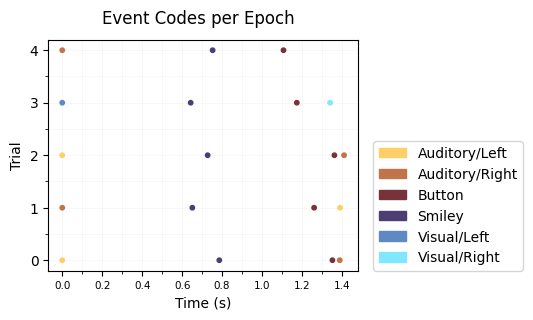

In [134]:
response_included = epochs_include_response.get_annotations_per_epoch()
display(response_included[0])

# plot the event code distributions
X__ = np.array([[tup[0], i] for i, sublist in enumerate(response_included) for tup in sublist])
labels = [tup[2] for sublist in response_included for tup in sublist]

uid = event_id.keys()
cmap = plt.get_cmap("managua", len(uid))
colors_map = {u: cmap(i) for i, u in enumerate(uid)}
colors = [colors_map[i] for i in labels]

fig, axes = plt.subplots(1, 1, figsize=(4, 3))
scatter = axes.scatter(X__[:,0], X__[:,1], c=colors, s=10)
axes.tick_params(axis="x", which="major", labelsize=7.5)
axes.set_xlabel("Time (s)", fontsize=10)
axes.tick_params(axis="y", which="major", labelsize=10)
axes.set_ylabel("Trial", fontsize=10)
axes.set_yticks([0, 1, 2, 3, 4])
axes.set_axisbelow(True)
axes.xaxis.set_minor_locator(AutoMinorLocator(2))
axes.yaxis.set_minor_locator(AutoMinorLocator(2))
axes.grid(linewidth=0.5, color="whitesmoke", which="major", zorder=1)
axes.grid(linewidth=0.5, color="whitesmoke", which="minor", zorder=0)

handles = [mpatches.Patch(color=list(colors_map.values())[i], label=list(colors_map.keys())[i])
           for i in range(len(colors_map))]
fig.legend(handles=handles,
                  loc="lower right",
                  bbox_to_anchor=(1.33, 0.087))
fig.suptitle("Event Codes per Epoch")
plt.show()

> MNE epoching logic is a bit different from EEGLAB bin-based epoching... You can sub-select epochs by looking-up / indexing the event description, and '/' serves as a <i>separator</i> (well, kind of).<br>- 𝒜𝓂𝒶𝓃𝒹𝒶 ℒ𝒾𝓃

In [135]:
print(f"type of epochs['Auditory/Right'] = {epochs['Auditory/Right']}")
aud = epochs["Auditory"]
aud_right = epochs["Auditory/Right"]
left = epochs["Left"]

type of epochs['Auditory/Right'] = <Epochs | 34 events (all good), -0.3 – 0.499 s (baseline -0.3 – 0 s), ~10.6 MiB, data loaded,
 np.str_('Auditory/Right'): 34>


> Honestly, I never understood "Global Field Power (GFP)" -- it sounded so fancy... Until I realized it's just standard deviation across channels, haha. Below I manually (by that I mean Numpy) conpute GFP and related metrics used in `epochs.plot_image()`, and use `pcolormesh` to plot MNE-like color maps. For reference, here's a description of GFP:<br><br>"<i>Another useful <strong>reference-free transformation</strong> is mean global field power. If you have a reasonable number and spread of electrodes, any given ERP component will produce a systematic gradient in the amplitude across electrode sites that is proportional to the amplitude of the internal generator. [...] The spread of voltage values across electrode sites is proportional to the amplitude of the N400. We can quantify this spread by taking the standard deviation across sites at any given time point. This standard deviation is called the global field power or GFP. Because the reference electrode contributes equally to each channel, it is effectively a constant and has no impact on the GFP.</i>"<br>(Applied Event-Related Potential Data Analysis, Steven J. Luck)<br><br> - 𝒜𝓂𝒶𝓃𝒹𝒶 ℒ𝒾𝓃

epochs['Visual'] data shape (n_epochs, n_channels, n_times) = (65, 59, 481)


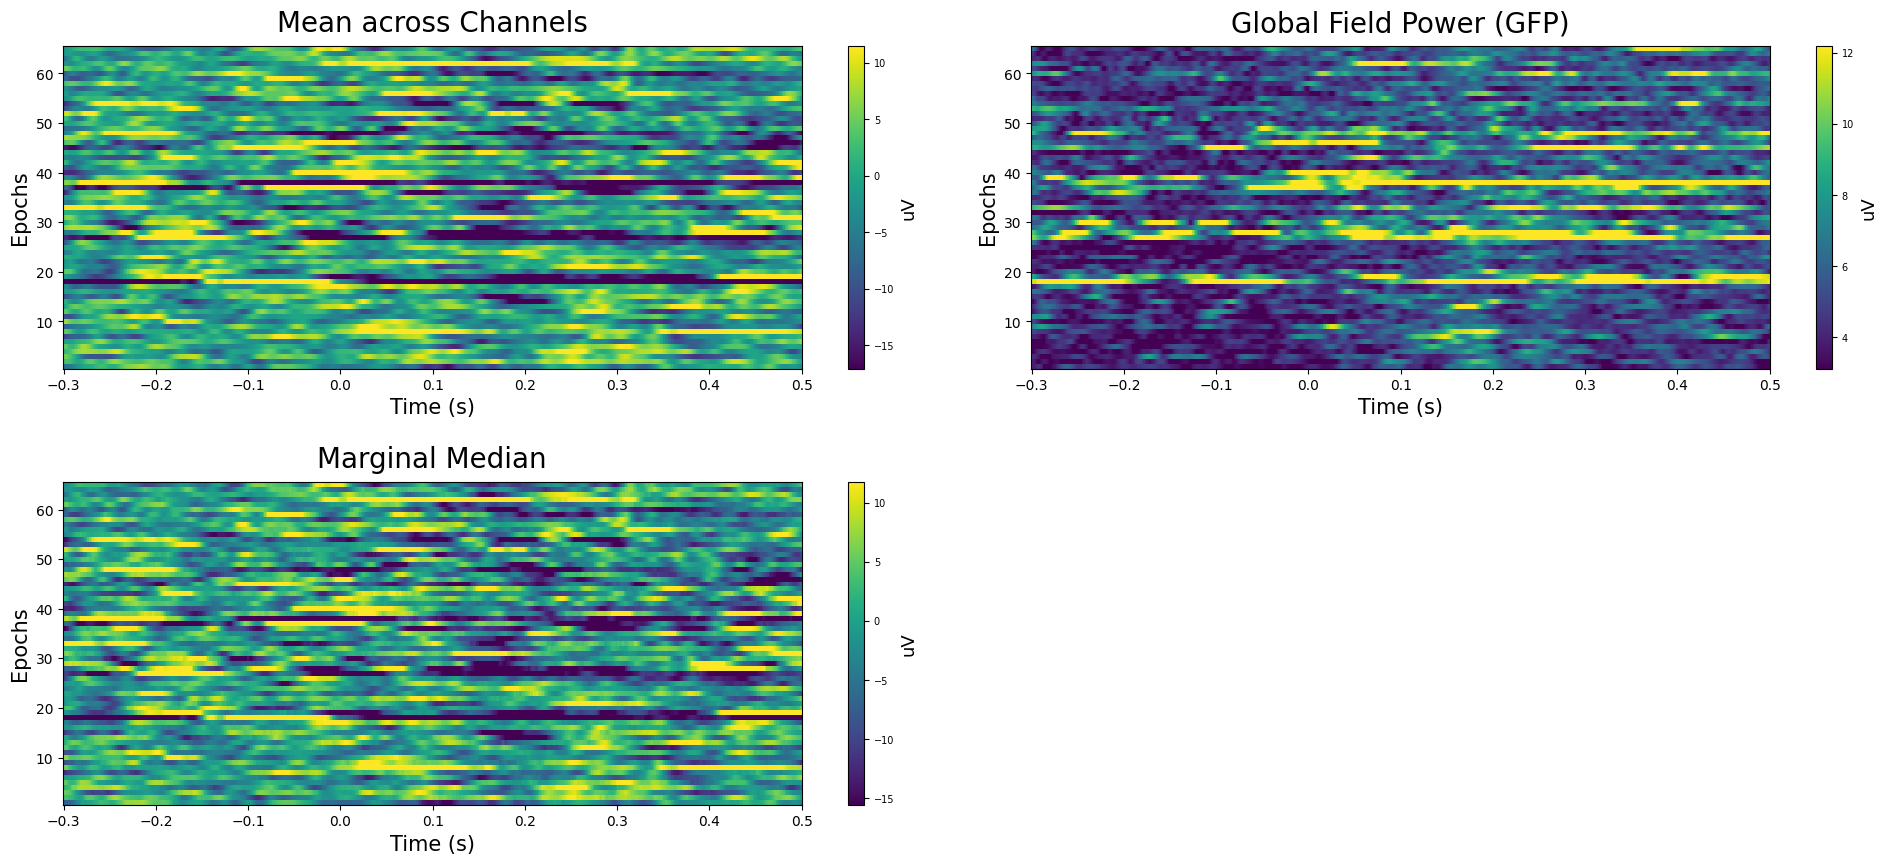

In [409]:
vis = epochs["Visual"]
print(f"epochs['Visual'] data shape (n_epochs, n_channels, n_times) = {vis.get_data().shape}")

def my_plot_image_eeg(epochs, ddof=0, custom_func=None, mean=True, gfp=True, median=True,
                              vmin=None, vmax=None, custom_title: str|None=None, **kwargs):
    data = epochs.get_data(picks=["eeg"], units="uV")
    sfreq = epochs.info["sfreq"]
    n_epochs, _, n_times = data.shape
    epochs_range = np.arange(1, n_epochs+1)
    times = np.arange(0, n_times)/sfreq - 0.3

    mean = data.mean(axis=1) if mean == True else None
    gfp = data.std(axis=1, ddof=ddof) if gfp == True else None # EEGLAB uses sample std (1/(N-1) in denominator)
    median = np.median(data, axis=1) if median == True else None

    data_transformed = None
    if custom_func:
        data_transformed = custom_func(data)
        assert data_transformed.shape == n_epochs, n_times
    
    mean_title = kwargs.get("mean_title", "Mean across Channels")
    gfp_title = kwargs.get("gfp_title", "Global Field Power (GFP)")
    median_title = kwargs.get("median_title", "Marginal Median")
    cmap = kwargs.get("cmap", "viridis" )
    
    figsize = kwargs.get("figsize", (20, 9))
    title_fontsize = kwargs.get("title_fontsize", 20)
    label_fontsize = kwargs.get("label_fontsize", 15)
    cbar_fontsize = kwargs.get("cbar_fontsize", 13)

    fig, axes = plt.subplots(2, 2, figsize=figsize) 
    for ax, to_plot, t in zip(axes.flatten(),
                           [mean, gfp, median, data_transformed],
                           [mean_title, gfp_title, median_title, custom_title]):
        if to_plot is None:
            ax.remove()
            continue
        pcm = ax.pcolormesh(
            times,
            epochs_range,
            to_plot,
            vmin=vmin(to_plot),
            vmax=vmax(to_plot),
            shading="nearest",
            cmap=cmap)
        #ax.set_xticks(np.array([times[0],times[20],times[40],times[60],times[80],times[-1]]))
        ax.set_xlabel("Time (s)", fontsize=label_fontsize, y=0.8)
        ax.set_ylabel("Epochs", fontsize=label_fontsize, x=0.5)
        ax.set_title(t, fontsize=title_fontsize, y=1.02)
        cbar = fig.colorbar(pcm)
        cbar.set_label(label="uV", fontsize=cbar_fontsize)
        cbar.ax.tick_params(labelsize=7)
    fig.tight_layout(pad=2)
    plt.show()

my_plot_image_eeg(vis, vmin=lambda X: np.percentile(X, 5),
                       vmax=lambda X: np.percentile(X, 95))

> Here's the MNE built-in `epochs.plot_image()`<br>- 𝒜𝓂𝒶𝓃𝒹𝒶 ℒ𝒾𝓃

Not setting metadata
65 matching events found
No baseline correction applied
0 projection items activated
combining channels using GFP (eeg channels)


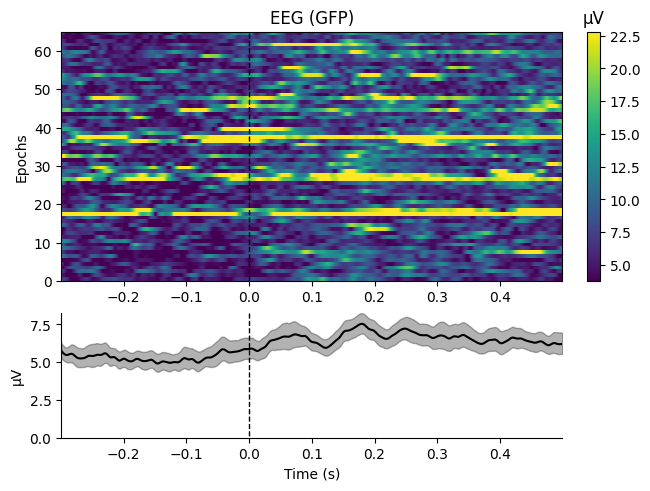

In [139]:
# %matplotlib inline
epochs["Visual"].plot_image(picks = "eeg",
                            vmin=lambda X: np.percentile(X, 5),
                            vmax=lambda X: np.percentile(X, 95),
                            sigma=0.1,
                            combine="gfp",
                            cmap="viridis",
                            evoked=True); # draw evoked (erp) image below

In [140]:
epochs_to_export.save(pathlib.Path("out_data") / "epochs_epo.fif", 
            overwrite=True, verbose=False)

[PosixPath('/Users/jowanglin/brainhack-ntu/bids-and-mne/mne_eeg_workshop/out_data/epochs_epo.fif')]

## Data Cleaning and Artifact Handling
Severe contamination of EEG activity by eye movements, blinks, muscle, heart and line noise is a serious problem for EEG interpretation and analysis. One method proposed to remove a wide variety of artifacts from EEG recordings is **Independent Component Analysis (ICA)**.

Independent components analysis (ICA) is a technique for estimating independent source signals from a set of recordings in which the source signals were mixed together in unknown ratios. 

We will apply ICA on our epoched data but this can be done directly on the filtered raw data as well.



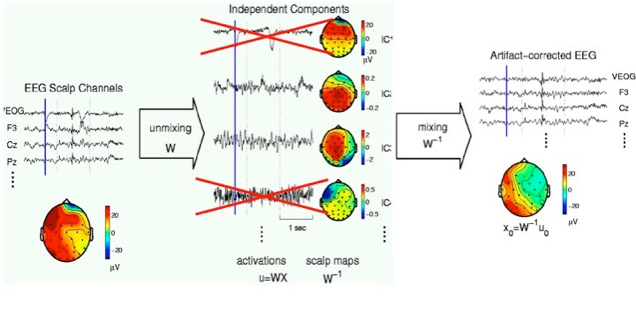

> <strong>WHAT DO ARTIFACTS (BLINKS, IN PARTICULAR) LOOK LIKE?</strong><br><br>(Function description copied from MNE documentation as I have never used this function before either)<br>`mne.preprocessing.create_eog_epochs()` <i>Conveniently generates epochs around EOG artifact events. This function will:<br>1. Filter the EOG data channel.<br>2. Find the peaks of eyeblinks in the EOG data using</i> `mne.preprocessing.find_eog_events()`<br><i>3. Create Epochs around the eyeblinks.</i><br><br>Here I'll first explore how `mne.preprocessing.find_eog_events()` works by trying to use this function to catch blinks in ERPLAB's epoch-based artifact-detection style: define a time window (peak_time - delta, peak_time + delta) around each peak blink event MNE identifies from the raw continuous waveform (because `mne.preprocessing.find_eog_events()` only takes Raw as input), and mark the epoch(s) that overlap(s) with a blink time window.<br><br><strong>Note that this is <i>artifact inspection/detection and epoch flagging</i>, not data preproessing for ICA.</strong><br><br>- 𝒜𝓂𝒶𝓃𝒹𝒶 ℒ𝒾𝓃

[add plot for marked epochs]

Creating RawArray with float64 data, n_channels=376, n_times=60213
    Range : 0 ... 60212 =      0.000 ...   100.251 secs
Ready.


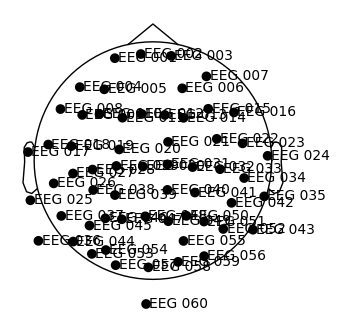

In [681]:
# load the raw and epochs from disk (in case you in-place modified them in one of the cells above)
RAW_ORIG_PATH = "sample_audvis_raw.fif"
EVENTS_TSV_PATH = "out_data/sample_BIDS/sub-01/ses-01/meg/sub-01_ses-01_task-audiovisual_run-01_events.tsv"
raw_orig = mne.io.read_raw_fif(RAW_ORIG_PATH, verbose=False, preload=True);
raw_cropped_filtered = raw_orig.copy().crop(tmax=100.25).filter(l_freq=1, h_freq=40,
                                                                method="fir",
                                                                verbose=False);

raw_obj = mne.io.RawArray(data=raw_cropped_filtered.get_data(), info=raw_cropped_filtered.info);
df_events = pd.read_csv(EVENTS_TSV_PATH, sep="\t")
ons, dura, desc = df_events["onset"], df_events["duration"], df_events["trial_type"]
new_annot = mne.Annotations(ons, dura, desc)
raw_obj.set_annotations(new_annot, verbose=False);
raw = raw_obj

epochs = mne.read_epochs(pathlib.Path("out_data") / "epochs_epo.fif", verbose=False);

# plot the channels so we know which ones are frontal (near Fp1 & Fp2 in 10-20 sys)
# looks like its EEG001 - EEG003
montage = epochs.info.get_montage()
ch_positions = montage.get_positions()

_, axes = plt.subplots(figsize=(4, 4))
fig = montage.plot(kind="topomap",
             scale=0.5,
             sphere="auto", 
             axes=axes,
             show=True)

In [616]:
# thresh:
# Threshold to trigger the detection of an EOG event. This controls the thresholding of the underlying peak-finding algorithm.
# Larger values mean that fewer peaks (i.e., fewer EOG events) will be detected.
# If None, use the default of (max(eog) - min(eog)) / 4, with eog being the filtered EOG signal.
THRESHOLD = 100          # in microvolts
L_FREQ, H_FREQ = 0, 30   # using my lab's params; MNE default is l_freq, h_freq = 1, 10
CH_NAME = ["EEG 001", "EEG 002", "EEG 003", "EOG 061"]  # EOG channel + frontal channel
eog_events = mne.preprocessing.find_eog_events(raw.copy(), event_id=100,
                                               l_freq=L_FREQ, h_freq=H_FREQ, filter_length="10s",  # lowpass filter 30 Hz (i am not sure about filter length)
                                               ch_name=CH_NAME,
                                               tstart=0,
                                               reject_by_annotation=False,
                                               thresh=THRESHOLD * 1e-6,
                                               verbose=True)
print(f"\n\nshape of eog_events: {eog_events.shape}")
print(f"    >> i.e., found {len(eog_events)} possible EOG events")
print(eog_events[:5])
print("...")

Using EOG channels: EEG 001, EEG 002, EEG 003, EOG 061
EOG channel index for this subject is: [315 316 317 375]
Filtering the data to remove DC offset to help distinguish blinks from saccades
Selecting channel EOG 061 for blink detection
Setting up low-pass filter at 30 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal lowpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 30.25 Hz)
- Filter length: 6007 samples (10.001 s)

Now detecting blinks and generating corresponding events
Found 24 significant peaks
Number of EOG events detected: 24


shape of eog_events: (24, 3)
    >> i.e., found 24 possible EOG events
[[  301     0   100]
 [ 1383     0   100]
 [ 2199     0   100]
 [ 8683     0   100]
 [18328     0   100]]
...


In [610]:
# Let's see how many of those overlap with our actual epoch time windows (-0.3, 0.5)
BLINK_WINDOW_HALF_LENGTH = 0.05
def is_in_epochs(eog_time, windows):
    def is_in_interval(interval: tuple, eog_time: tuple):
        overlap = max(0, min(interval[1], eog_time[1]) - max(interval[0], eog_time[0]))
        if overlap > 0:
            return True
        else:
            return False
    check = np.array([is_in_interval(interval, eog_time) for interval in windows])
    idx = np.where(check==True)[0]
    if idx.size > 0 :
        return list(np.where(check==True)[0])
    else:
        return [-1]
    
sfreq = epochs.info["sfreq"]
starts = (epochs.events.T[0]) - 0.3 * sfreq
ends = (epochs.events.T[0]) + 0.5 * sfreq
windows = np.array([(s, e) for s, e in zip(starts, ends)], dtype=object)

eog_events_times = [(t - BLINK_WINDOW_HALF_LENGTH * sfreq, t + BLINK_WINDOW_HALF_LENGTH * sfreq)
                            for t in eog_events.T[0]] # blink "windows" surrounding each peak blink event
epoch_nums = sum([is_in_epochs(eog_time, windows) for eog_time in eog_events_times], [])
set_epoch_nums = sorted(set(epoch_nums))
set_epoch_nums.remove(-1)
set_epoch_nums = np.array(set_epoch_nums) + 1
print(f"Epochs indices (already +1 to align with EEGLAB) flagged for blinks:\n   {set_epoch_nums}")


Epochs indices (already +1 to align with EEGLAB) flagged for blinks:
   [  1  16  38  40  41  56  57  58  59  60  65  66  68  69  75  76  77  78
  79  82  93  94  95  98  99 111 122 126 133]


> If you have EEGLAB and have exported the epochs as an SET file, you can look at these epochs indices (already +1 because MATLAB indexing starts from 1, not 0) in Plot > Channel data (scroll). In my opinion, I think it catches blinks reasonably well.<br>- 𝒜𝓂𝒶𝓃𝒹𝒶 ℒ𝒾𝓃

shape of data_to_plot = (12, 4, 121)


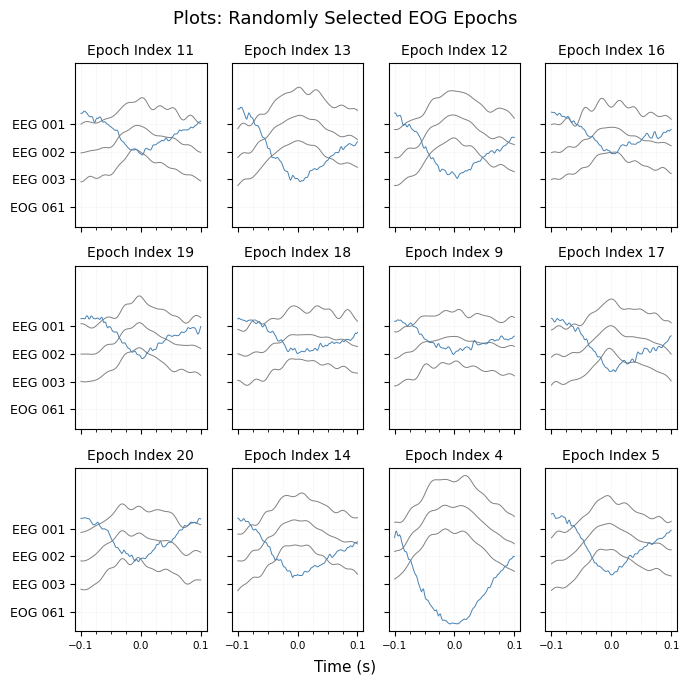

In [ ]:
# creating epochs surrouding eog events using create eog_epochs
import random
eog_epochs = create_eog_epochs(raw.copy(), event_id=100,
                               l_freq=L_FREQ, h_freq=H_FREQ, 
                               ch_name=CH_NAME,
                               picks = CH_NAME,
                               tmin = - BLINK_WINDOW_HALF_LENGTH * 2,
                               tmax = BLINK_WINDOW_HALF_LENGTH * 2,
                               baseline = None,
                               decim = 1,  # don't downsample
                               flat = None,
                               reject_by_annotation=False,
                               thresh=THRESHOLD * 1e-6,
                               preload = True,
                               verbose=False);

# randomly select 12 of those epochs to plot
indices_to_plot = random.sample(range(len(eog_epochs)), 12)
data_to_plot = eog_epochs.get_data(units={"eeg": "uV", "eog": "uV"})[indices_to_plot]
print(f"shape of data_to_plot = {data_to_plot.shape}")

labels = CH_NAME
ver_offsets = - data_to_plot.mean() * np.arange(4)
times = np.linspace(-0.1, 0.1, data_to_plot.shape[2])  

fig, axes = plt.subplots(3, 4, figsize=(7, 7), sharex=True, sharey=True)
for (i, ax), idx in zip(enumerate(axes.flatten()), indices_to_plot):
    for j in range(4):
        y = data_to_plot[i, j] + ver_offsets[j]  
        color = "grey" if j < 3 else "steelblue"
        ax.plot(times, y, color=color, linewidth=0.7)
    ax.set_axisbelow(True)
    ax.xaxis.set_minor_locator(AutoMinorLocator(4))
    ax.grid(linewidth=0.5, color="whitesmoke", which="major", zorder=1)
    ax.grid(linewidth=0.5, color="whitesmoke", which="minor", zorder=0)
    ax.set_yticks(ver_offsets)
    ax.set_yticklabels(labels, fontsize=9)
    ax.tick_params(axis="x", which="major", labelsize=7.5)
    ax.set_title(f"Epoch Index {idx}", fontsize=10)

fig.supxlabel("Time (s)", fontsize=11, y=0.03)
fig.suptitle("Plots: Randomly Selected EOG Epochs", fontsize=13)
fig.tight_layout()
plt.show()


> Note that frontal and EOG channels show inverse polarity!<br>- 𝒜𝓂𝒶𝓃𝒹𝒶 ℒ𝒾𝓃

### Fitting and Plotting the ICA Solution
> <i>Mathmatically</i>, ICA n_components can be anywhere between 1 and n_channels: 1 <= n_components <= n_chennels. <i>Practically</i>, especially in EEG land, both MNE and EEGLAB recommend keeping as many components as the data matrix rank allows. The original version of this notebook uses 20 ICs... hmmm maybe let's do 50 (we have 59 good EEG channels)<br>- 𝒜𝓂𝒶𝓃𝒹𝒶 ℒ𝒾𝓃

In [564]:
X = epochs.get_data(units="uV")
n_epochs, n_channels, n_times = X.shape
print(f"EEG channels only epochs data shape (n_epochs, n_channels, n_times) = {X.shape}")

# MNE uses np.hstack, faster than X = epochs.get_data().transpose(2, 0, 1).reshape(n_channels, n_samples)
X = np.hstack(X).T
n_samples, _ = X.shape
assert n_samples == n_epochs * n_times
print(f"shape after np.stack (n_samples, n_channels) = {X.shape}")

print(f"rank of data matrix = {np.linalg.matrix_rank(X, tol=1e-2)}")
S = np.linalg.svd(X, full_matrices=False, compute_uv=False)
print(f"Number of singular values of X (data matrix stacked) = {len(S)}; min = {round(min(S), 2)}; max = {round(max(S), 2)}")


EEG channels only epochs data shape (n_epochs, n_channels, n_times) = (133, 59, 481)
shape after np.stack (n_samples, n_channels) = (63973, 59)
rank of data matrix = 59
Number of singular values of X (data matrix stacked) = 59; min = 101.61; max = 19273.52


In [565]:
N_COMPONENTS = 50
METHOD = "infomax"
MAX_ITER = 1000
RANDOM_STATE = 42
VERBOSE=True 
NOISE_COV = None 

FIT_PARAMS={"extended": True,         # EEGLAB default is infomax extended
            "weights": None,          # The initialized unmixing matrix. Defaults to None, which means the identity matrix is used.
            "l_rate": None,           # This quantity indicates the relative size of the change in weights. Defaults to 0.01 / log(n_features ** 2).
            "block": None,            # The block size of randomly chosen data segments. Defaults to floor(sqrt(n_times / 3.)).
            "w_change": 1e-12,        # The change at which to stop iteration. Defaults to 1e-12.
            "anneal_deg": 60.0,       # The angle (in degrees) at which the learning rate will be reduced. Defaults to 60.0.
            "anneal_step": 0.9,        # The factor by which the learning rate will be reduced. Defaults to 0.9.
            "n_subgauss": 1,          # The number of subgaussian components. Only considered for extended Infomax. Defaults to 1.
            "kurt_size": 6000,        # The window size for kurtosis estimation. Only considered for extended Infomax. Defaults to 6000.
            "blowup": 10000}          # The maximum difference allowed between two successive estimations of the unmixing matrix. Defaults to 10000.


ica = mne.preprocessing.ICA(n_components=N_COMPONENTS,
                            noise_cov=NOISE_COV,
                            random_state=RANDOM_STATE,
                            method=METHOD,
                            fit_params=FIT_PARAMS,
                            max_iter=MAX_ITER,
                            verbose=VERBOSE)
ica.fit(epochs)

Fitting ICA to data using 59 channels (please be patient, this may take a while)
Selecting by number: 50 components
Computing Extended Infomax ICA


/var/folders/n3/nqqvqq1n0jx25dfd3nyxjxmh0000gn/T/ipykernel_35646/1611813552.py:27: RuntimeWarning: The epochs you passed to ICA.fit() were baseline-corrected. However, we suggest to fit ICA only on data that has been high-pass filtered, but NOT baseline-corrected.
  ica.fit(epochs)


Fitting ICA took 6.6s.


Method,infomax
Fit parameters,extended=Trueweights=Nonel_rate=Noneblock=Nonew_change=1e-12anneal_deg=60.0anneal_step=0.9n_subgauss=1kurt_size=6000blowup=10000max_iter=1000
Fit,1000 iterations on epochs (63973 samples)
ICA components,50
Available PCA components,59
Channel types,eeg
ICA components marked for exclusion,—


> Below, some linear algebra checks (because I'm a math nerd XD)<br>- 𝒜𝓂𝒶𝓃𝒹𝒶 ℒ𝒾𝓃

In [144]:
from sklearn.decomposition import PCA

print(f">> LINEAR ALGEBRA CHECKS")
cov_matrix = np.cov(X, rowvar=False)            # rowar=False: each column represents a variable, while the rows contain observations.
print(f"   - Shape of covariance matrix = {cov_matrix.shape}")
print(f"   - Determinant of covariance matrix = {np.linalg.det(cov_matrix):.2e}")

pca = PCA(n_components=n_channels, whiten=True, random_state=RANDOM_STATE) # passing n_components=n_cahnnels to sklearn because mne stores all of them
pca.fit(X)
# singular values = eigen values for cov_matrix = (X-μ).T @ (X-μ) since (X-μ).T @ (X-μ) is symmetric
sing_vals = pca.singular_values_
X_pca_components = pca.components_
print(f"   - Shape of PCA principal axes, i.e., the eigen basis, (n_channels, n_channels) = {X_pca_components.shape}")

# eigen basis vectors inner product -> should be the identity matrix:
id_matrix = np.diag([1]*n_channels)
result = X_pca_components.T @ X_pca_components
delta_norm = np.linalg.norm(result - id_matrix)
print(f"   - Eigen basis orthonormal? Difference compared to identity matrix = {delta_norm:.2e}")
print(f"   - Covariance matrix singular values (= eigen values ∵ symmetric and positive semidefinite):\n{sing_vals}\n")

all_close = np.array([np.allclose(x, y) if np.allclose(x, y) else np.allclose(-x, y)
             for x, y in zip(X_pca_components, ica.pca_components_)])  # unit eigen vectors are unique up to sign (+/-)
check = np.where(all_close==False)[0]
suffix = "" if len(check) == 0 else f" Except for indices {check}!"
print(f">> Sklearn-extracted pricipal axes (i.e., eigen vector directions) are all identical to MNE.{suffix}")

>> LINEAR ALGEBRA CHECKS
   - Shape of covariance matrix = (59, 59)
   - Determinant of covariance matrix = 3.61e+42
   - Shape of PCA principal axes, i.e., the eigen basis, (n_channels, n_channels) = (59, 59)
   - Eigen basis orthonormal? Difference compared to identity matrix = 9.20e-15
   - Covariance matrix singular values (= eigen values ∵ symmetric and positive semidefinite):
[19197.51301772  8369.32924711  4103.2339994   3754.00807609
  2465.90746569  2254.39579741  1989.82350393  1880.7766006
  1625.07131782  1531.94837938  1467.4613217   1411.86799771
  1313.10530705  1250.6724677   1193.31961766  1083.37451972
  1014.57736269  1007.7279063    961.45896313   954.31393545
   923.73231785   905.52869951   836.3167977    783.99179108
   736.40466617   708.12047175   655.19895127   624.20713213
   594.94607053   545.20330565   535.99193737   519.66515436
   502.70082921   484.52377514   420.7905037    381.27037341
   338.17993923   318.56330305   308.04569089   296.75812384
   277

In [ ]:
# get sources (ICA space)
epochs_sources = ica.get_sources(epochs)

# You can view the IC sources time series in EEGLAB using Plot -> Channel data (scroll)
mne.export.export_epochs("epochs_sources.set", epochs_sources, fmt="eeglab", overwrite=True, verbose=False)

> <strong>NERD NOTE ON MNE ICA'S <i>CHANNEL NAME BOOKKEEPING</i></strong><br><br>MNE stores the entire (n_channels, n_channels) eigen basis as `ica.pca_components_`. If you're familiar with linear algebra, you might wonder what happens if we call `ica.get_sources(another_instance)` where `another_instance` has fewer channels than the initial instance the ICA object was fint on? Mathematically, this shouldn't work because there aren't enough principal axes (i.e., the eigen vectors) by which to multiply the data matrix in `another_instance`. Well, turns out I was <i>very surprised</i> that it did not error when I tried it! Then I asked ChatGPT and found out that MNE actually doesn't match matrix shape; it matches <i>channel names</i>.  So even if `another_instance` has more channels than the initial instance, as long as MNE is able to select -- based on ch_names -- the channels that match the ones ica was fit on, it'll still run and just ignore the rest of the channels. On the other hand, suppose you do `ica.get_sources(third_instance)` where the channels in `third_instance` don't match the ones ica was fit on, it will throw a ValueError. For example, my lab's data is 33 channels, 10-20 system.<br><br>- 𝒜𝓂𝒶𝓃𝒹𝒶 ℒ𝒾𝓃

In [ ]:
import warnings
warnings.filterwarnings("ignore")

path_to_lab_data = "path.set"
my_epochs = mne.read_epochs_eeglab(path_to_lab_data, verbose=False);
print(f"First five channel names (10-20 sys): {epochs.ch_names[:5]}")

try:
    ica.get_sources(my_epochs)
except ValueError as e:
    print(e)

warnings.resetwarnings()

First five channel names (10-20 sys): ['EEG 001', 'EEG 002', 'EEG 003', 'EEG 004', 'EEG 005']
No channels match the selection.


> Before we plot the fancy-looking component topo maps, I think it's important we take a deeper look at what exactly we're plotting: the component topo maps illustrate a sequence of linear mappings/transformations: the mixing matrix (operator from ICA source space to PCA space), and the PCA principal axes matrix (operator from PCA space back to sensor/channel space). MNE then projects this sequence of linear maps onto scalp topography. You can get this linear map sequence as numpy arrays by calling `ica.get_components()`. Below I implement the manual matrix multiplication version.<br><br>I will then try to plot the 2D `plt.imshow` version of the topo map... The distribution kind of makes sense (first two components have a frontal distribution resembling that of eye artifacts), but still, MNE topo maps have scaling, interpolation, and possibly some whitening.<br><br>- 𝒜𝓂𝒶𝓃𝒹𝒶 ℒ𝒾𝓃

>> Yup, manual matrix multiplication matches ica.get_components() perfectly!


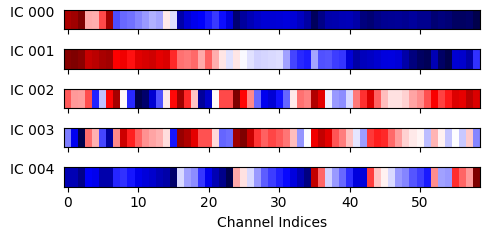

In [202]:
zero_padding = np.zeros((ica.n_components, n_channels - ica.n_components))
proj = np.concat([ica.mixing_matrix_.T, zero_padding], axis=1) @ ica.pca_components_  # np.linalg.inv(ica.pca_components_.T) = ica.pca_components_
proj_ = proj[:5]

topo_arrays = ica.get_components().T
if np.array_equal(proj, topo_arrays):
    print(f">> Yup, manual matrix multiplication matches ica.get_components() perfectly!")

fig, axes = plt.subplots(5, 1, figsize=(5, 2.5), sharex=True)
for i, ax in enumerate(axes):
    row = topo_arrays[i][np.newaxis, :]  # make it 2D (1 x 50)
    im = ax.imshow(row, aspect="auto", cmap="seismic")
    ax.set_ylabel(f"IC 00{i}", rotation=0, labelpad=23)
    ax.set_yticks([])  # hide y ticks since it's just 1 row

axes[-1].set_xlabel("Channel Indices")
plt.tight_layout()
plt.show()

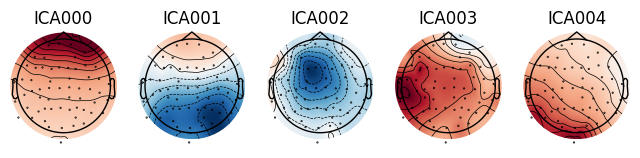

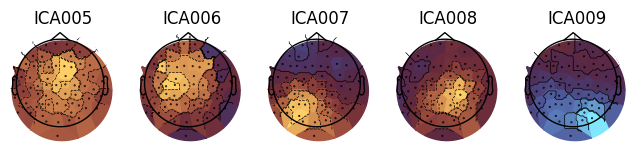

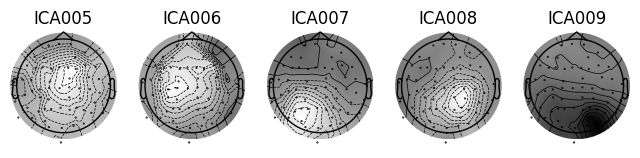

In [809]:
_, axes = plt.subplots(1, 5, figsize=(8, 8))
ica.plot_components(picks=range(5), axes=axes,
                    extrapolate="head", image_interp="cubic", show=True, contours=8);

_, axes = plt.subplots(1, 5, figsize=(8, 8))
ica.plot_components(picks=range(5, 10), axes=axes,
                    extrapolate="head", image_interp="nearest", show=True, cmap="managua");

_, axes = plt.subplots(1, 5, figsize=(8, 8))
ica.plot_components(picks=range(5, 10), axes=axes,
                    extrapolate="head", image_interp="linear", show=True, cmap="binary", contours=10);

> Before we use MNE's built-in `ica.plot_properties()`, I'll demonstrate plotting the figures using matplotlib from scratch.<br>- 𝒜𝓂𝒶𝓃𝒹𝒶 ℒ𝒾𝓃

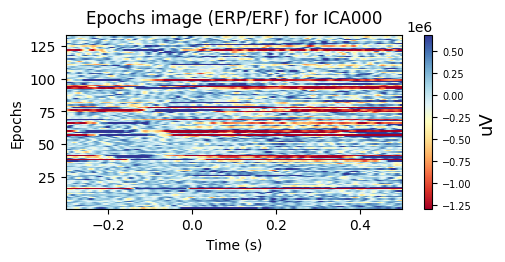

In [410]:
# this basically is just that components time series stacked together in the y (epochs )axis 
ica000_epochs = mne.EpochsArray(epochs_sources.copy().get_data()[:, 0, :][np.newaxis, :, :].transpose(1, 0, 2), 
                                mne.create_info(["ICA000"], epochs_sources.info["sfreq"], ch_types="eeg"), verbose=False);

my_plot_image_eeg(ica000_epochs, cmap="RdYlBu", vmin=lambda X: np.percentile(X, 5),
                  vmax=lambda X: np.percentile(X, 95), median=False, gfp=False,
                  figsize=(10, 5), mean_title="Epochs image (ERP/ERF) for ICA000",
                  title_fontsize=12, label_fontsize=10, cbar_fonsize=8)

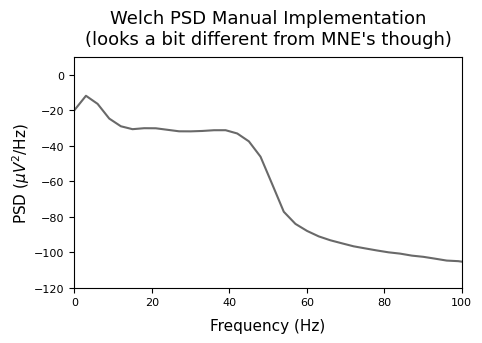

In [438]:
from scipy.signal import get_window, welch

xs = epochs_sources.copy().get_data()[:, 0, :]
Nx, overlap, sfreq = 200, 0.5, epochs_sources.info["sfreq"]
w = get_window("hann", Nx, fftbins=True)

psds = np.array([welch(x, fs=sfreq,
             window=w,
             nperseg=Nx,
             noverlap=Nx*overlap,
             nfft=None,
             detrend="constant",  
             return_onesided=True,
             scaling="density",
             average="mean")[1] for x in xs])
log_mean_psd = 10 * np.log10(psds.mean(axis=0) + 1e-12 )

f = welch(xs[0], fs=sfreq,
             window=w,
             nperseg=Nx,
             noverlap=Nx*overlap,
             nfft=None,
             detrend="constant",  
             return_onesided=True,
             scaling="density",
             average="mean")[0]

fig, axes = plt.subplots(1, 1, figsize=(5, 3))
axes.plot(f, log_mean_psd, linewidth=1.5, color="dimgrey")
axes.set_xlim(0, 100)
axes.set_ylim(-120, 10)
axes.set_xlabel("Frequency (Hz)", fontsize=11, y=0)
axes.set_ylabel(r"PSD ($\mu V^2$/Hz)", fontsize=11)
axes.set_title("Welch PSD Manual Implementation\n(looks a bit different from MNE's though)", fontsize=13, y=1.02)
axes.tick_params(axis="both", which="major", labelsize=8)
axes.xaxis.set_label_coords(0.5, -0.13)
axes.yaxis.set_label_coords(-0.11, 0.5)

note if you need to rerun ICA you need to delete the ica instance saved in memory ` del ica `

Effective window size : 0.801 (s)
Not setting metadata
133 matching events found
No baseline correction applied
0 projection items activated


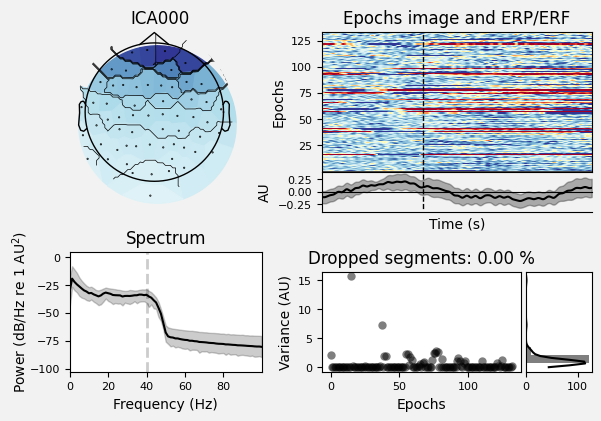

In [ ]:
topomap_args = {"cmap": "RdYlBu", "image_interp": "nearest", "contours": 10}
image_args = {"vmin": lambda X: np.percentile(X, 5),
              "vmax": lambda X: np.percentile(X, 95),
              "cmap": "RdYlBu"}
psd_args = {"fmax": 100, "method": "welch"}
ica.plot_properties(epochs,picks =[0],
                    figsize=(6, 4),
                    verbose="INFO",
                    topomap_args=topomap_args,
                    image_args=image_args,
                    psd_args=psd_args,
                    log_scale=False,
                    estimate="power"); # for psd

In [ ]:
#%matplotlib qt
#ica.plot_sources(epochs, show_scrollbars=False);

[insert eeglab screenshot]

### Selecting ICA Components Manually
For more info on visually identifying Independent Components, this [EEGLAB guide](https://labeling.ucsd.edu/tutorial/labels) is a good resource.

Let's say we decided to remove the first component, we can plot and see what the signal looks like before and after exclusion using an overlay plot.

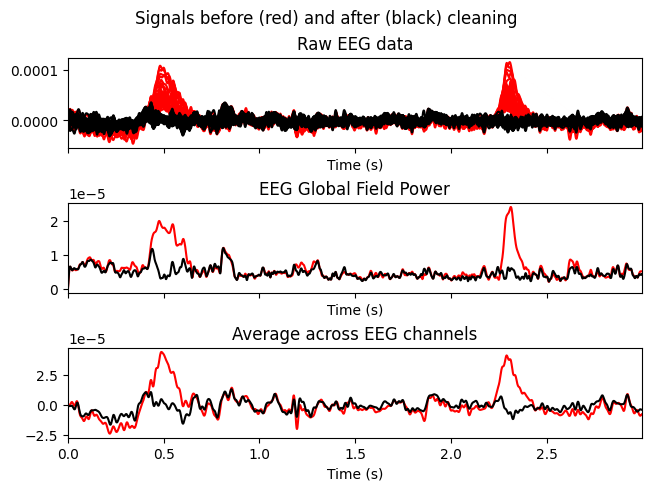

In [251]:
#%matplotlib inline
ica.plot_overlay(raw, exclude=[0], verbose='WARNING');

#### Apply the exclusion

In [299]:
ica.exclude = [0] 
# ica.apply() changes the Raw object in-place, so let's make a copy first:
reconst_epochs = epochs.copy()
ica.apply(reconst_epochs);

Applying ICA to Epochs instance
    Transforming to ICA space (50 components)
    Zeroing out 1 ICA component
    Projecting back using 59 PCA components


/var/folders/n3/nqqvqq1n0jx25dfd3nyxjxmh0000gn/T/ipykernel_35646/3885252443.py:4: RuntimeWarning: The data you passed to ICA.apply() was baseline-corrected. Please note that ICA can introduce DC shifts, therefore you may wish to consider baseline-correcting the cleaned data again.
  ica.apply(reconst_epochs);


#### Plot and compare before vs after ICA

In [ ]:
#%matplotlib qt
#epochs.plot();
#reconst_epochs.plot();

[insert eeglab screenshot]

## Creating Evoked Data
Now we can create evoked responses for each condition

In [377]:
evokeds = epochs.average(method="mean", by_event_type=True) # method: how to combine the data.
                                                            # If "mean"/"median", the mean/median are returned.
                                                            # Otherwise, must be a callable which, when passed an array of shape (n_epochs, n_channels, n_time)
                                                            # returns an array of shape (n_channels, n_time). 
print(f"type of evokeds = {type(evokeds)}")
print(f"len(evokeds) = {len(evokeds)}")

event_types = [evoked.comment for evoked in evokeds]
print(f"The evoked objects in the list correspons to the following events:\n    {event_types}")

type of evokeds = <class 'list'>
len(evokeds) = 4
The evoked objects in the list correspons to the following events:
    ['Auditory/Left', 'Auditory/Right', 'Visual/Left', 'Visual/Right']


#### Basic visualization of Evoked objects
We can visualize the average evoked response for the auditory stimuli using the plot() method, which yields a butterfly plot of each channel type. Like many MNE-Python plotting functions, evoked.plot() has a picks parameter that can select channels to plot by name, index, or type. We will specifically look at EEG channels.

In [ ]:
# combining evokeds to get all auditory, but we need to weigh by their counts
aud_left_count = sum(np.where(epochs.events.T[2]==epochs.event_id["Auditory/Left"], 1, 0))
aud_right_count = sum(np.where(epochs.events.T[2]==epochs.event_id["Auditory/Right"], 1, 0))
denominator = aud_left_count + aud_right_count

evoked_aud = mne.combine_evoked([evokeds[event_types.index("Auditory/Left")],
                                 evokeds[event_types.index("Auditory/Right")]],
                                 weights=[aud_left_count/denominator, aud_right_count/denominator])

# but of course, we could've also done this
evoked_aud_ = epochs["Auditory"].average()  # method='mean' by default; by_event_type=False by default

print(f"Are these two evokeds indistinguishably close (np.all_close)?  {np.allclose(evoked_aud.get_data(), evoked_aud_.get_data())}")

Are these two evokeds indistinguishably close (np.all_close)?  True


> <strong>REMEMBER (VERY IMPORTANT)</strong><br> In MNE, EEG/ERP data structure is represented in the following 3 classes, and they correspond to EEGLAB operations as well:<br><br>`mne.io.Raw` Raw data. Array of shape (n_channels, n_times)<br>`mne.Epochs` Epoched data. Array of shape (n_epochs, n_channels, n_times)<br>`mne.Evoked` Averaged ERPs. Array of shape (n_channels, n_times). In EEGLAB, the file extension is `.erp`.<br><br>- 𝒜𝓂𝒶𝓃𝒹𝒶 ℒ𝒾𝓃

In [439]:
print(f"shape of evoked_aud data array (n_channels, n_times) = {evoked_aud.get_data().shape}")

shape of evoked_aud data array (n_channels, n_times) = (59, 481)


In an interactive session, the butterfly plots seen above can be click-dragged to select a time region, which will pop up a map of the average field distribution over the scalp for the selected time span. You can also generate scalp topographies seperately or jointly at specific times or time spans using the plot_topomap() method.

In [ ]:
evoked_aud.plot(spatial_colors=True, picks = ['eeg']);
evoked_auditory.plot_topomap(ch_type='eeg');

Joint plots combine butterfly plots with scalp topographies, and provide an excellent first-look at evoked data; by default, topographies will be automatically placed based on peak finding. 

In [ ]:
evoked_auditory.plot_joint(picks='eeg');

Here we compare evoked responses by looking at the global field power (an average-referenced RMS)

In [ ]:
mne.viz.plot_compare_evokeds([evoked_auditory, evoked_visual], picks='eeg');

#### Saving Evoked Data

In [ ]:
mne.write_evokeds(fname=pathlib.Path('out_data') / 'evokeds_ave.fif',
                  evoked=[evoked_auditory, evoked_visual],overwrite=True)

### Automatic Artifact Handling: Using an EOG/ECG channel to select ICA components
It may have seemed easy to review the plots and manually select which ICs to exclude, but when processing dozens or hundreds of subjects this can become a tedious, rate-limiting step in the analysis pipeline. One alternative is to use dedicated EOG or ECG sensors as a “pattern” to check the ICs against, and automatically mark for exclusion any ICs that match the EOG/ECG pattern.

We apply this to the raw data

> (Copied from MNE documentation as I have never used this function before either)<br><br>`ICA.find_bads_eog()` <i>Detects EOG related components using correlation. Detection is based on Pearson correlation between the filtered data and the filtered EOG channel. Thresholding is based on adaptive z-scoring. The above threshold components will be masked and the z-score will be recomputed until no supra-threshold component remains.</i><br><br>- 𝒜𝓂𝒶𝓃𝒹𝒶 ℒ𝒾𝓃

In [596]:
# re-instantiate ica and refit
N_COMPONENTS = 50
METHOD = "infomax"
MAX_ITER = 1000
RANDOM_STATE = 42
VERBOSE=True 
NOISE_COV = None 

FIT_PARAMS={"extended": True,         
            "weights": None,          
            "l_rate": None,           
            "block": None,            
            "w_change": 1e-12,        
            "anneal_deg": 60.0,       
            "anneal_step": 0.9,        
            "n_subgauss": 1,         
            "kurt_size": 6000,        
            "blowup": 10000}          

ica = mne.preprocessing.ICA(n_components=N_COMPONENTS,
                            noise_cov=NOISE_COV,
                            random_state=RANDOM_STATE,
                            method=METHOD,
                            fit_params=FIT_PARAMS,
                            max_iter=MAX_ITER,
                            verbose=VERBOSE)

# fit ica only to eeg 
epochs_eeg = epochs.copy()
epochs_eeg = epochs_eeg.pick(picks="eeg") # picks="eeg" by default exclues "bads"
ica.fit(epochs_eeg)

Fitting ICA to data using 59 channels (please be patient, this may take a while)
Selecting by number: 50 components
Computing Extended Infomax ICA


/var/folders/n3/nqqvqq1n0jx25dfd3nyxjxmh0000gn/T/ipykernel_35646/593552560.py:31: RuntimeWarning: The epochs you passed to ICA.fit() were baseline-corrected. However, we suggest to fit ICA only on data that has been high-pass filtered, but NOT baseline-corrected.
  ica.fit(epochs_eeg)


Fitting ICA took 6.7s.


Method,infomax
Fit parameters,extended=Trueweights=Nonel_rate=Noneblock=Nonew_change=1e-12anneal_deg=60.0anneal_step=0.9n_subgauss=1kurt_size=6000blowup=10000max_iter=1000
Fit,1000 iterations on epochs (63973 samples)
ICA components,50
Available PCA components,59
Channel types,eeg
ICA components marked for exclusion,—


Using EOG channel: EOG 061
EOG channel index for this subject is: [375]
Filtering the data to remove DC offset to help distinguish blinks from saccades
Selecting channel EOG 061 for blink detection
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 6007 samples (10.001 s)

Now detecting blinks and generating corresponding events
Found 14 significant peaks
Number of EOG events detected: 14
Not setting metadata
14 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 3)
Using data from preloaded Raw for 14 events and 601 original time points 

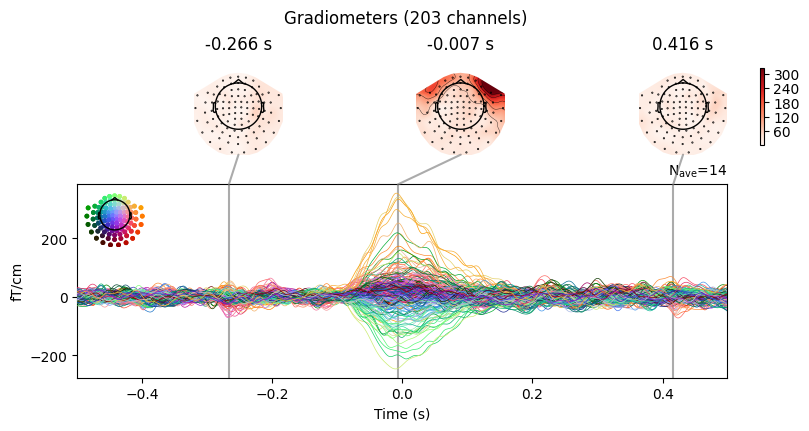

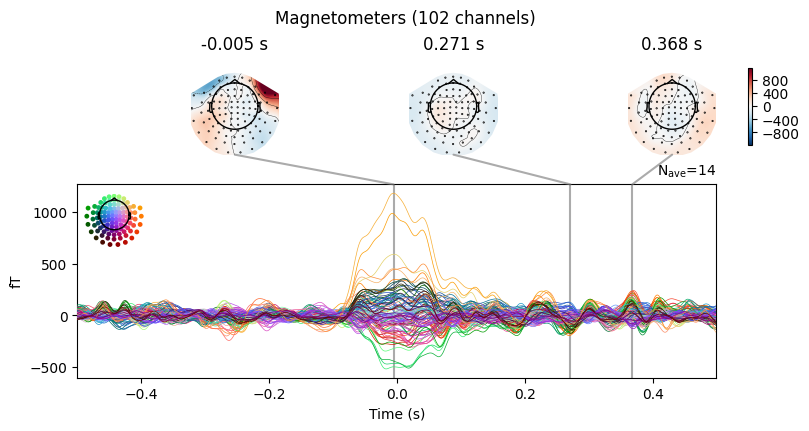

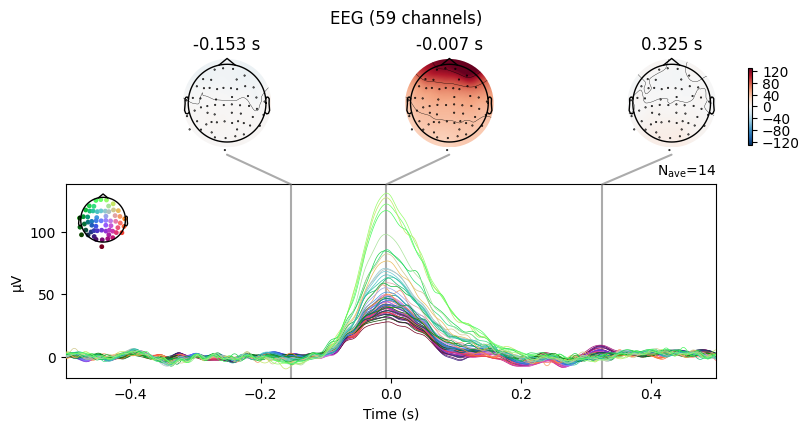

In [677]:
eog_evoked = create_eog_epochs(raw).average()
eog_evoked.apply_baseline(baseline=(None, -0.2))
eog_evoked.plot_joint();

Using EOG channel: EOG 061
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 6007 samples (10.001 sec)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


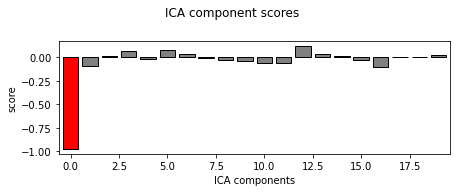

    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
50 matching events found
No baseline correction applied
0 projection items activated


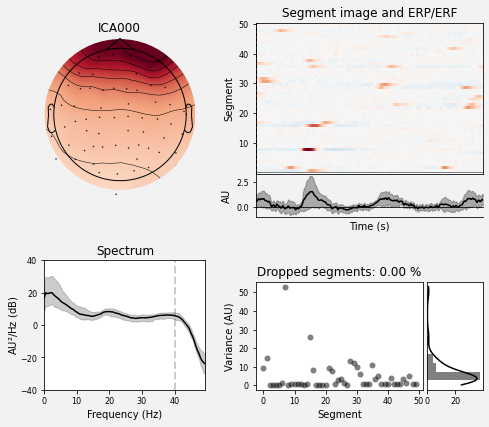

Creating RawArray with float64 data, n_channels=21, n_times=60062
    Range : 25800 ... 85861 =     42.956 ...   142.955 secs
Ready.


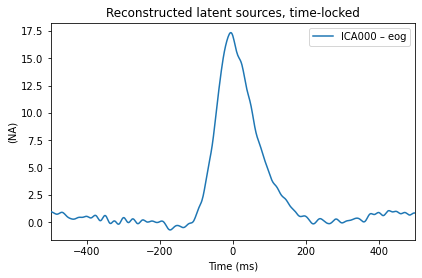

In [34]:
ica.exclude = []
# find which ICs match the EOG pattern
eog_indices, eog_scores = ica.find_bads_eog(raw)
ica.exclude = eog_indices

# barplot of ICA component "EOG match" scores
ica.plot_scores(eog_scores);

# plot diagnostics
ica.plot_properties(raw, picks=eog_indices);

# plot ICs applied to raw data, with EOG matches highlighted
ica.plot_sources(raw);

# plot ICs applied to the averaged EOG epochs, with EOG matches highlighted
ica.plot_sources(eog_evoked, picks=0);

> <strong>Below: 𝒜𝓂𝒶𝓃𝒹𝒶 ℒ𝒾𝓃 added SSP (signal space projection) for repairing EOG artifacts</strong>

[consider adding orthogonal projection and svd math here]

In [1002]:
from mne.preprocessing import compute_proj_eog
from time import perf_counter

raw_for_proj = raw.copy()
raw_for_proj.pick(picks=["eeg", "eog"]).drop_channels(raw_for_proj.info["bads"]).del_proj()

eog_epochs = create_eog_epochs(raw_for_proj.copy(),
                               event_id=100,
                               l_freq=0, h_freq=30, 
                               ch_name=CH_NAME,
                               picks = "all",
                               tmin = -0.2,
                               tmax = 0.2,
                               baseline = None,
                               decim = 1,     # don't downsample
                               flat = None,
                               reject_by_annotation=False,
                               thresh=None,   # Use default threshold, i.e., default of (max(eog) - min(eog)) / 4, with eog being the filtered EOG signal.
                                              # so it matches the eog_events found by compute_proj_eog 
                               preload = True, 
                               verbose=False)
eog_evoked = eog_epochs.average(picks="all")
print(f"Shape of eog_epochs = {eog_epochs.get_data().shape}\n")

# Trying 3 projectors
eog_projs, eog_events, drop_log = compute_proj_eog(
             raw_for_proj,
             copy=True,
             tmin = -0.2,
             tmax = 0.2,
             event_id=100,
             l_freq=1, h_freq=40,
             eog_l_freq=0, eog_h_freq=30, filter_length="10s",
             tstart=0.0,
             filter_method="fir",
             ch_name=CH_NAME,
             return_drop_log=True,
             n_eeg=3,
             reject=None,
             average=True,    # If average=True, SSP is computed after eog_epochs.average()
             n_jobs=-1,
             avg_ref=False,   # don't add average reference as a projector
             verbose=False);
assert np.array_equal(eog_epochs.events, eog_events)

print(f"Found {len(eog_events)} EOG events.")
print(f"Drop log should be empty since reject=None: {drop_log}")
display(eog_projs)
print(f"Type of each Projectione = {type(eog_projs[0])}")
print(f"The Projection class is a subclass of dict: {issubclass(type(eog_projs[0]), dict)}")
print(eog_projs[0].keys())


Shape of eog_epochs = (17, 60, 241)

Found 17 EOG events.
Drop log should be empty since reject=None: ((), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), ())


[<Projection | EOG-eeg--0.200-0.200-PCA-01, active : False, n_channels : 59, exp. var : 98.78%>,
 <Projection | EOG-eeg--0.200-0.200-PCA-02, active : False, n_channels : 59, exp. var : 0.95%>,
 <Projection | EOG-eeg--0.200-0.200-PCA-03, active : False, n_channels : 59, exp. var : 0.07%>]

Type of each Projectione = <class 'mne._fiff.proj.Projection'>
The Projection class is a subclass of dict: True
dict_keys(['desc', 'kind', 'active', 'data', 'explained_var'])


> I suspect by "n_eeg projection vectors", MNE probably calculates something like the first n_eeg PCA components (principal axes) of the EOG data matrix, or something similar to that... Let's test my hypothesis using `sklearn.decomposition.PCA` to get the principal axes and compute the dot products between them and the MNE projection vectors (i.e., cosine similarity as they are all unit vectors), for directions are unique up to sign flips and there's filtering involved, I don't expect `np.array_equal()` or `np.allclose()` to return True.<br>- 𝒜𝓂𝒶𝓃𝒹𝒶 ℒ𝒾𝓃

In [980]:
proj_vecs = np.array([eog_projs[i]["data"]["data"] for i in range(len(eog_projs))]).squeeze(axis=1).T
print(f"Shape of projector vectors (I stacked them): {proj_vecs.shape}")
print(f"Rank of stacked projector vectors: {np.linalg.matrix_rank(proj_vecs, tol=1e-2)}")

eog_data = eog_evoked.copy().get_data(picks="eeg", units="uV").T
# MNE probably does something like this if average=False in compute_proj_eog
# eog_data = np.hstack(eog_epochs.copy().get_data(picks="eeg", units="uV")).T  
pca = PCA(n_components=proj_vecs.shape[0], whiten=True, random_state=RANDOM_STATE) 
pca.fit(eog_data)
eigen_vecs = pca.components_
explained_var = [float(round(var/np.sum(pca.explained_variance_), 4)) for var in pca.explained_variance_[:3]]

directional_alignment = [float(abs(v1.T @ v2)) for v1, v2 in zip(eigen_vecs[:3], proj_vecs.T)]
print(f"\n>> Directional alignment (absolute cosine similarity scores):\n      {directional_alignment}")
print(f">> Explained variance:\n      {explained_var}")


Shape of projector vectors (I stacked them): (59, 3)
Rank of stacked projector vectors: 3

>> Directional alignment (absolute cosine similarity scores):
      [0.9999655157321384, 0.998724173753265, 0.990352157667379]
>> Explained variance:
      [0.9874, 0.0097, 0.0008]


> Well, those are very high absolute cosine similarity scores (and the explained variance scores also kind of match)! Conclusion: there's strong evidence that `mne.preprocessing.compute_proj_eog()` computes the projector vectors using a PCA/SVD-based algorithm. However, unless we read the source code, we won't know exactly how it's done. Next, we implement orthogonal projection and see if it matches MNE's `.apply_proj()`.<br>- 𝒜𝓂𝒶𝓃𝒹𝒶 ℒ𝒾𝓃

In [981]:
data_for_proj = raw_for_proj.get_data(picks="eeg", units="uV")
proj_vecs = np.array([eog_projs[i]["data"]["data"] for i in range(len(eog_projs))]).squeeze(axis=1).T
print(f"Shape of projector vectors (I stacked them): {proj_vecs.shape}")
print(f"Rank of stacked projector vectors: {np.linalg.matrix_rank(proj_vecs, tol=1e-2)}")

# Using standard projection matrix X @ inv(X.T @ X) @ X.T (Gram-Schmidt)
start1 = perf_counter()
proj_matrix = proj_vecs @ np.linalg.inv(proj_vecs.T @ proj_vecs) @ proj_vecs.T
my_cal1 = (np.eye(data_for_proj.shape[0]) - proj_matrix) @ data_for_proj 
end1 = perf_counter()
delta1 = end1 - start1

# Using SVD
start2 = perf_counter()
U, _, __ = np.linalg.svd(proj_vecs, full_matrices=False)  # compact svd
proj_matrix = U @ U.T
my_cal2 = (np.eye(data_for_proj.shape[0]) - proj_matrix) @ data_for_proj
end2 = perf_counter()
delta2 = end2 - start2

print(f"Shape of projection matrix (n_eeg_channels, n_eeg_channels): {proj_matrix.shape}")
print(f"Rank of data after projection (should be n_eeg_channels -3): {np.linalg.matrix_rank(my_cal1, tol=1e-2)}\n")

raw_projected = raw_for_proj.copy()
raw_projected.add_proj(eog_projs)
raw_projected.apply_proj()
mne_cal = raw_projected.get_data(units="uV", picks="eeg")

print(f"""\n >> Both manual orthogonal projection calculations identical to MNE .apply_proj():
    {all([np.allclose(my_cal1, my_cal2), np.allclose(my_cal1, mne_cal), np.allclose(my_cal2, mne_cal)])}""")
print(f"    ... (Not expecting much difference due to tiny matrix size but let's check) compact SVD is faster/slower by {1e-3 * (delta1 - delta2)} ms.")


Shape of projector vectors (I stacked them): (59, 3)
Rank of stacked projector vectors: 3
Shape of projection matrix (n_eeg_channels, n_eeg_channels): (59, 59)
Rank of data after projection (should be n_eeg_channels -3): 56

3 projection items deactivated
Created an SSP operator (subspace dimension = 3)
3 projection items activated
SSP projectors applied...

 >> Both manual orthogonal projection calculations identical to MNE .apply_proj():
    True
    ... (Not expecting much difference due to tiny matrix size but let's check) compact SVD is faster/slower by 1.4119590050540865e-06 ms.


> Projector topomap means, for example, if frontal channels correspond to channels indices 0, 1, 2, ..., then a typical blink projector should have reletively large absolute values at indices 0, 1, 2, ...<br>𝒜𝓂𝒶𝓃𝒹𝒶 ℒ𝒾𝓃

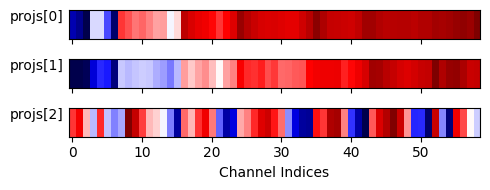

In [982]:
fig, axes = plt.subplots(3, 1, figsize=(5, 2), sharex=True)
for i, ax in enumerate(axes):
    row = proj_vecs.T[i][np.newaxis, :]
    im = ax.imshow(row, aspect="auto", cmap="seismic")
    ax.set_ylabel(f"projs[{i}]", rotation=0, labelpad=23,)
    ax.set_yticks([])  

axes[-1].set_xlabel("Channel Indices")
plt.tight_layout()
plt.show()

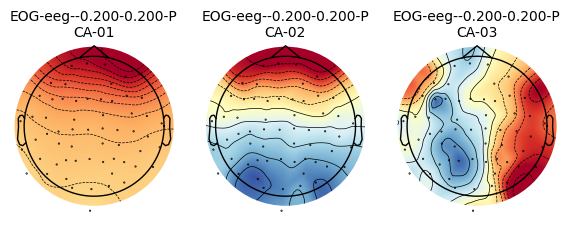

In [847]:
_, axes = plt.subplots(1, 3, figsize=(7, 7))
mne.viz.plot_projs_topomap(eog_projs, info=raw_for_proj.info, axes=axes,
                    extrapolate="head", image_interp="cubic", cmap="RdYlBu", contours=10, show=True);

3 projection items deactivated


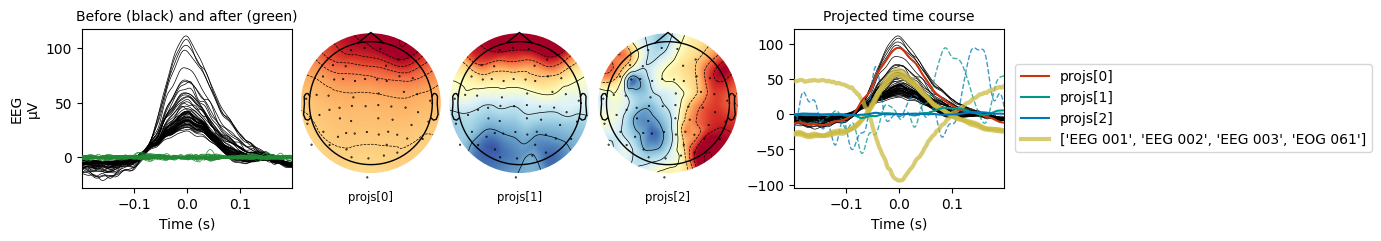

In [848]:
fig = mne.viz.plot_projs_joint(eog_projs, eog_evoked, topomap_kwargs={"cmap": "RdYlBu"}, picks_trace=CH_NAME)

In [1000]:
# Let's just add the first two projections
raw_for_proj.add_proj(eog_projs[:2])
display(raw_for_proj.info["projs"])

2 projection items deactivated


[<Projection | EOG-eeg--0.200-0.200-PCA-01, active : False, n_channels : 59, exp. var : 98.78%>,
 <Projection | EOG-eeg--0.200-0.200-PCA-02, active : False, n_channels : 59, exp. var : 0.95%>]

> You can export the SSPed raw data as an SET file and view the waveforms in EEGLAB with much more clarity and a better GUI.<br>- 𝒜𝓂𝒶𝓃𝒹𝒶 ℒ𝒾𝓃

In [1003]:
# adding blink event markers using eog_events
annot_for_proj = raw_for_proj.copy().annotations
raw_for_proj.set_annotations(None)
onset_desc = [(ons, desc) for ons, desc in zip(annot_for_proj.onset, annot_for_proj.description)]
blinks = [(ons/sfreq, "blink") for ons in eog_events.T[0]]
merged = onset_desc + blinks
merged.sort(key=lambda x: x[0]) # sort by onset time
annot_merged = mne.Annotations(onset=[m[0] for m in merged],
                               duration=[0 for m in merged],
                               description=[m[1] for m in merged])
raw_for_proj.set_annotations(annot_merged, verbose=False);
events_merged, event_id_merged = mne.events_from_annotations(raw_for_proj)

# If you want to add the events array, you need to add a STIM channel
# (because I dropped STIM and MEG channels when I created raw_for_proj)
#zero_raw = mne.io.RawArray(data=np.zeros((1, raw_for_proj.n_times)),
                           #info=mne.create_info(["ghost"], sfreq=sfreq, ch_types=["stim"]))
#raw_for_proj.add_channels([zero_raw], force_update_info=True)
#raw_for_proj.add_events(events_merged)

mne.export.export_raw(f"before-ssp.set", raw_for_proj,
                      fmt="eeglab", overwrite=True, verbose=True)   # export before ssp
raw_ssp = raw_for_proj.copy()
raw_ssp.apply_proj()
mne.export.export_raw(f"after-ssp.set", raw_ssp,
                      fmt="eeglab", overwrite=True, verbose=True)   # export after ssp

Used Annotations descriptions: [np.str_('Auditory/Left'), np.str_('Auditory/Right'), np.str_('Button'), np.str_('Smiley'), np.str_('Visual/Left'), np.str_('Visual/Right'), np.str_('blink')]
Overwriting existing file.
No projector specified for this dataset. Please consider the method self.add_proj.
Overwriting existing file.


[add ssp screenshots]

#### ECG

Reconstructing ECG signal from Magnetometers
Setting up band-pass filter from 8 - 16 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 8.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 7.75 Hz)
- Upper passband edge: 16.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 16.25 Hz)
- Filter length: 6007 samples (10.001 sec)

Number of ECG events detected : 99 (average pulse 59 / min.)
Not setting metadata
99 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 3)
Using data from preloaded Raw for 99 events and 601 original time points ...
0 bad epochs dropped
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 3)
3 projection items activated
SSP projectors applied...
Removing projector <Projection | PCA-

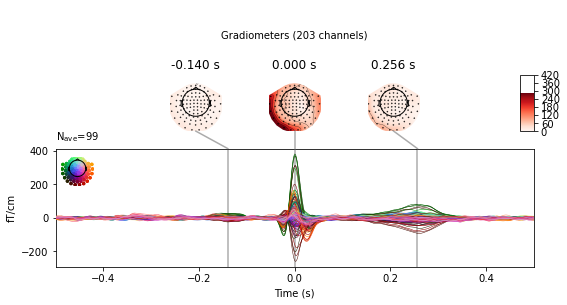

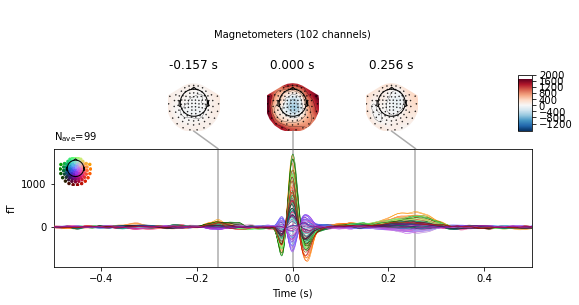

Removing projector <Projection | PCA-v1, active : True, n_channels : 102>
Removing projector <Projection | PCA-v2, active : True, n_channels : 102>
Removing projector <Projection | PCA-v3, active : True, n_channels : 102>


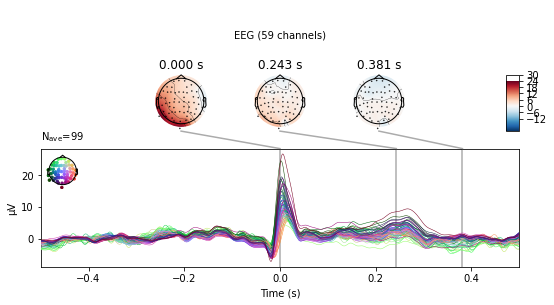

In [35]:
ecg_evoked = create_ecg_epochs(raw).average()
ecg_evoked.apply_baseline(baseline=(None, -0.2))
ecg_evoked.plot_joint();

Reconstructing ECG signal from Magnetometers
Using threshold: 0.21 for CTPS ECG detection
Reconstructing ECG signal from Magnetometers
Setting up band-pass filter from 8 - 16 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 8.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 7.75 Hz)
- Upper passband edge: 16.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 16.25 Hz)
- Filter length: 6007 samples (10.001 sec)

Number of ECG events detected : 99 (average pulse 59 / min.)
Not setting metadata
99 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 3)
Using data from preloaded Raw for 99 events and 601 original time points ...
0 bad epochs dropped


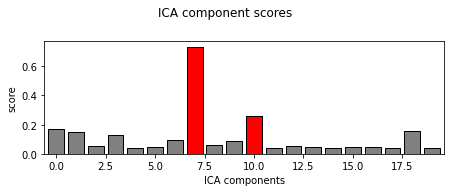

    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
50 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
50 matching events found
No baseline correction applied
0 projection items activated


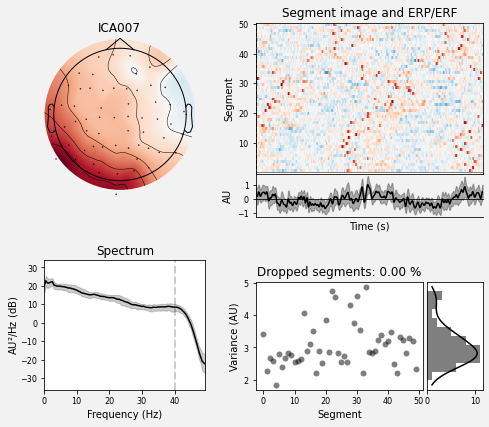

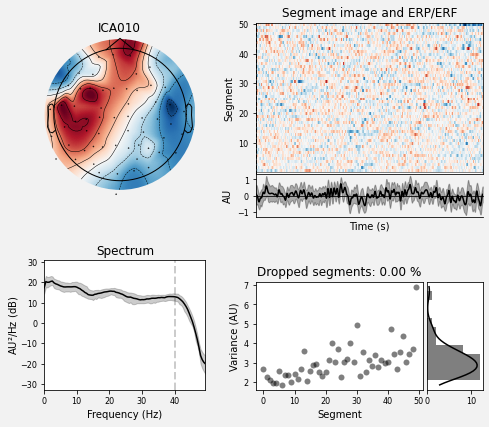

Creating RawArray with float64 data, n_channels=21, n_times=60062
    Range : 25800 ... 85861 =     42.956 ...   142.955 secs
Ready.


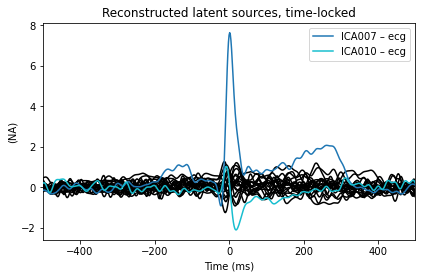

In [36]:
ica.exclude = []
# find which ICs match the ECG pattern
ecg_indices, ecg_scores = ica.find_bads_ecg(raw)
ica.exclude = ecg_indices

# barplot of ICA component "ECG match" scores
ica.plot_scores(ecg_scores)

# plot diagnostics
ica.plot_properties(raw, picks=ecg_indices)

# plot ICs applied to raw data, with ECG matches highlighted
ica.plot_sources(raw, show_scrollbars=False)

# plot ICs applied to the averaged ECG epochs, with ECG matches highlighted
ica.plot_sources(ecg_evoked);

# Refrences

**MNE-Python** - 
Alexandre Gramfort, Martin Luessi, Eric Larson, Denis A. Engemann, Daniel Strohmeier, Christian Brodbeck, Roman Goj, Mainak Jas, Teon Brooks, Lauri Parkkonen, and Matti S. Hämäläinen. MEG and EEG data analysis with MNE-Python. Frontiers in Neuroscience, 7(267):1–13, 2013. doi:10.3389/fnins.2013.00267.


### Exercise #2

1) Read the file 'sub-s01_task-faceFO_eeg.fif' as an epoched object

2) Make a joint plot of the time-series? 

3) Create a variable with the array of the evoked data

4) Decompose the data using SVD (use the function  `numpy.linalg.svd`)


5) Make a `matplotlib` figure with 1 row and 5 columns and plot the first 5 components using the function `mne.viz.plot_topomap`